# CryptoStatArb — Strategy Graveyard

**Companion to [`research.ipynb`](research.ipynb).** That notebook is deliberately EDA-only; *this* one
holds every strategy we tested and rejected, with the code and the number that actually killed it.

Prose summary lives in [`docs/strategy_log.md`](docs/strategy_log.md) — this is the executable version.

## How to read this
Each section states the **hypothesis**, the **test**, and the **killing result**. "Dead" means *not
significantly profitable after realistic costs and out-of-sample scrutiny* — not "the code broke."

| # | Strategy | Verdict | Killed by |
|---|----------|---------|-----------|
| 1 | Intraday hour→hour predictability (Wen) | dead | significant cells ≈ false-positive rate |
| 2 | Directional lag-1 reversal (daily) | dead | edge concentrated in illiquid names |
| 3 | Cross-sectional reversal portfolio | dead as taker | 20 bps market cost erases gross Sharpe |
| 4 | Liquid-coin momentum, two-sided | weak | short leg negative; pooled SR 0.18–0.24 |
| 5 | Correlation / pairs mean-reversion | dead | rolling de-meaning manufactures the reversion |
| 6 | Hourly pair reversion | dead | bid-ask bounce; 1h execution delay erases it |

**The recurring lesson:** almost every apparent edge we found was either (a) the bid-ask spread we
would have had to pay to harvest it, or (b) an artifact of the transformation used to measure it.

## Setup

Self-contained — this notebook does not import from `research.ipynb`.

In [1]:
# --- Core libs ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import itertools, warnings
from pathlib import Path
from scipy import stats
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')
%matplotlib inline

DATA_DIR = Path('data')
ANN_DAILY  = 365
ANN_HOURLY = 365 * 24

def bps(x):
    """basis points -> decimal (20 -> 0.0020)."""
    return x / 1e4

# Binance.US cost assumptions (see research.ipynb for sourcing)
COST_LIMIT_BPS, COST_MARKET_BPS = 7.0, 20.0

In [2]:
# --- Metrics helpers (same conventions as research.ipynb) ---
def sharpe(ret, ann=ANN_DAILY):
    return ret.mean() / ret.std() * np.sqrt(ann)

def equity_curve(ret):
    return (1 + ret.fillna(0)).cumprod()

def drawdown(equity):
    return equity / equity.expanding(min_periods=1).max() - 1

def max_drawdown(ret):
    return drawdown(equity_curve(ret)).min()

def turnover(port):
    return (port.fillna(0) - port.shift().fillna(0)).abs().sum(1)

def beta(strat_ret, benchmark_ret):
    d = pd.concat([strat_ret, benchmark_ret], axis=1).dropna()
    return sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1])).fit().params.iloc[1]

def performance_summary(strat_ret, port=None, benchmark=None, ann=ANN_DAILY, name='strategy'):
    return pd.Series({
        'ann_return':   strat_ret.mean() * ann,
        'ann_vol':      strat_ret.std() * np.sqrt(ann),
        'sharpe':       sharpe(strat_ret, ann),
        'avg_turnover': turnover(port).mean() if port is not None else np.nan,
        'max_drawdown': max_drawdown(strat_ret),
        'beta':         beta(strat_ret, benchmark) if benchmark is not None else np.nan,
    }, name=name)

In [3]:
# --- Data: daily log prices / returns for all 60 coins, plus the real order-book spread ---
close  = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')['Close']
dclose = close.resample('1D').last()
logpx  = np.log(dclose)
logret = logpx.diff()

real_spread = pd.read_pickle(DATA_DIR / 'real_spread_bps.pk')   # median live spread, bps, per symbol
LIQUID = real_spread[real_spread < 10].index.tolist()           # the genuinely tradeable universe

split_ix = int(len(logret) * 0.80)                              # chronological 80/20, no shuffling
idx_tr, idx_te = logret.index[:split_ix], logret.index[split_ix:]

print(f'daily panel {logret.shape} | {logret.index.min().date()} -> {logret.index.max().date()}')
print(f'train -> {idx_tr.max().date()} | test {idx_te.min().date()} ->')
print(f'liquid universe (<10 bps): {len(LIQUID)} -> {sorted(s[:-4] for s in LIQUID)}')
print(f'median real spread across all 60: {real_spread.median():.0f} bps '
      f'| coins > 50 bps: {int((real_spread > 50).sum())}/60')

daily panel (1701, 60) | 2022-01-01 -> 2026-08-28
train -> 2025-09-21 | test 2025-09-22 ->
liquid universe (<10 bps): 9 -> ['ADA', 'AVAX', 'BNB', 'BTC', 'DOGE', 'ETH', 'LTC', 'SOL', 'ZEC']
median real spread across all 60: 85 bps | coins > 50 bps: 41/60


---
# 1. Intraday hour→hour predictability (Wen et al.) — **dead**

**Hypothesis.** An earlier hour's return predicts a later hour's return within the same UTC day —
crypto shows both intraday momentum *and* reversal, unlike equities.

**Test.** For every ordered pair of hours `(j → k)`, `j < k`, regress `r_k = a + b·r_j` across days
and map the t-stat. Run on BTC/ETH/XRP/SOL/LTC.

**The catch that decides it:** 276 hour-pairs per coin means ~14 false positives per coin at 5%. Only
cells **consistent across coins** count.

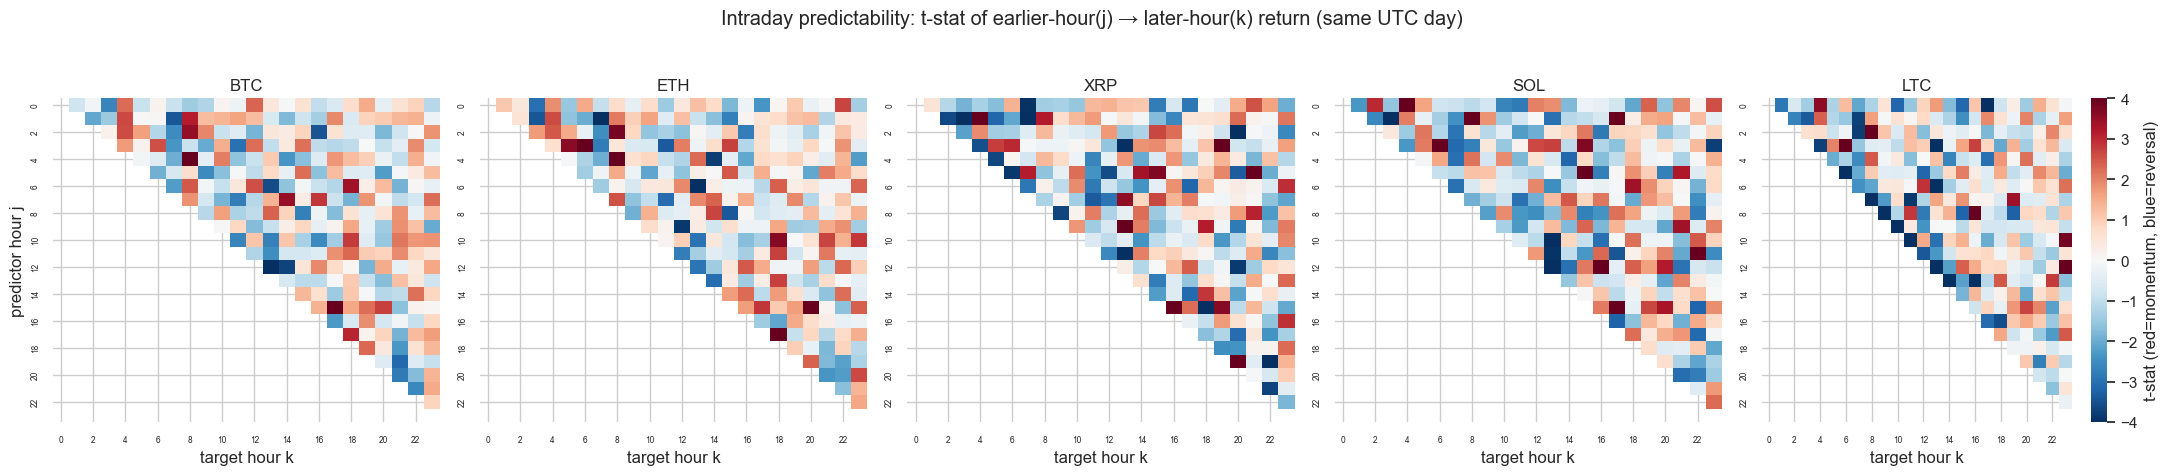

coin   pairs  sig_mom  sig_rev   (|t| > 1.96)
BTC      276       28       27
ETH      276       34       28
XRP      276       37       50
SOL      276       41       51
LTC      276       24       49

Most consistent MOMENTUM lead-lags j→k (avg t across 5 coins):
pred_h  tgt_h
3       6       3.8600
15      17      3.0700
5       15      3.0600
1       8       3.0500
4       8       2.9700
1       4       2.7400

Most consistent REVERSAL lead-lags j→k:
pred_h  tgt_h
1       7       -3.9600
12      13      -3.6200
1       3       -3.5500
11      13      -3.4700
7       11      -3.2100
6       13      -3.1900


In [4]:
# --- Intraday predictability: earlier-hour(j) -> later-hour(k) return, same UTC day ---
INTRADAY_COINS = ['BTC', 'ETH', 'XRP', 'SOL', 'LTC']

def hourly_logret(tk):
    c = (pd.read_pickle(DATA_DIR / 'xrp_hourly.pk')['Close'] if tk == 'XRP'
         else pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')['Close'][tk + 'USDT'])
    return np.log(c).diff()

def day_hour_matrix(tk):
    """(day × 24) matrix of hourly log returns; columns = hour-of-day 0..23 (UTC)."""
    r = hourly_logret(tk).dropna()
    M = r.groupby([r.index.normalize(), r.index.hour]).first().unstack()
    M = M.reindex(columns=range(24)); M.columns.name = 'tgt_h'; M.index.name = 'day'
    return M

def intraday_tgrid(tk):
    """t-stat of slope in r_k = a + b·r_j for every earlier hour j < later hour k (== t of corr)."""
    M = day_hour_matrix(tk); n = len(M); C = M.corr()
    with np.errstate(invalid='ignore', divide='ignore'):
        T = C * np.sqrt((n - 2) / (1 - C ** 2))
    T = T.where(np.triu(np.ones_like(T, dtype=bool), k=1))    # predictor(row j) < target(col k)
    T.index.name = 'pred_h'; T.columns.name = 'tgt_h'
    return T

tgrids = {c: intraday_tgrid(c) for c in INTRADAY_COINS}

fig, axes = plt.subplots(1, 5, figsize=(22, 4.6))
for i, (ax, c) in enumerate(zip(axes, INTRADAY_COINS)):
    sns.heatmap(tgrids[c], cmap='RdBu_r', vmin=-4, vmax=4, center=0, ax=ax,
                cbar=(i == 4), cbar_kws={'label': 't-stat (red=momentum, blue=reversal)'})
    ax.set_title(c); ax.set_xlabel('target hour k'); ax.tick_params(labelsize=6)
    ax.set_ylabel('predictor hour j' if i == 0 else '')
fig.suptitle('Intraday predictability: t-stat of earlier-hour(j) → later-hour(k) return (same UTC day)', y=1.03)
fig.tight_layout(); plt.show()

# significant-cell counts + cross-coin consensus
print(f'{"coin":5}{"pairs":>7}{"sig_mom":>9}{"sig_rev":>9}   (|t| > 1.96)')
for c in INTRADAY_COINS:
    v = tgrids[c].stack().values
    print(f'{c:5}{v.size:>7}{int((v > 1.96).sum()):>9}{int((v < -1.96).sum()):>9}')

avg_t = pd.concat([tgrids[c].stack().rename(c) for c in INTRADAY_COINS], axis=1).mean(axis=1)
print('\nMost consistent MOMENTUM lead-lags j→k (avg t across 5 coins):')
print(avg_t.sort_values(ascending=False).head(6).round(2).to_string())
print('\nMost consistent REVERSAL lead-lags j→k:')
print(avg_t.sort_values().head(6).round(2).to_string())

In [5]:
print('VERDICT — dead. Significant cells arrive at roughly the false-positive rate (~14 expected per')
print('coin at 5%), with no cross-coin consensus on which hour-pairs matter. No standalone intraday')
print('timing edge; the apparent structure is multiple-testing noise.')

VERDICT — dead. Significant cells arrive at roughly the false-positive rate (~14 expected per
coin at 5%), with no cross-coin consensus on which hour-pairs matter. No standalone intraday
timing edge; the apparent structure is multiple-testing noise.


---
# 2. Directional lag-1 reversal, daily conditional means — **dead**

**Hypothesis.** Group each coin's daily return by the **sign of yesterday's** return. If
mean-after-down > mean-after-up, the coin reverses.

`rev_spread = mean(after-down) − mean(after-up)`, positive ⇒ reversal. Welch t-test on the two
conditional means. Daily bars, where bid-ask bounce is far weaker than hourly.

In [6]:
# --- Directional lag-1 reversal: per-ticker conditional means ---
def ticker_frame(tk):
    """HW-style frame: current daily log return, its lag-1, and the +1/-1 direction of each."""
    df = pd.DataFrame({'close_log_return': logret[tk]})
    df['close_log_return_lag_1'] = df['close_log_return'].shift(1)
    for col in ['close_log_return', 'close_log_return_lag_1']:
        df[f'{col}_dir'] = df[col].map(lambda x: 1 if x > 0 else -1)
    return df.dropna()

# Every ticker's groupby table (return conditioned on the SIGN of the prior day's return):
rev_tables = {tk: ticker_frame(tk)
                    .groupby('close_log_return_lag_1_dir')
                    .aggregate({'close_log_return': ['mean', 'count', 'sum']})
              for tk in logret.columns}

# Examples (call rev_tables['SOLUSDT'] etc. for any ticker):
print('BTC — return grouped by prior-day direction:')
display(rev_tables['BTCUSDT'])
print('ETH:')
display(rev_tables['ETHUSDT'])

BTC — return grouped by prior-day direction:


close_log_return              
                                       mean count     sum
close_log_return_lag_1_dir                               
-1                                  -0.0002   858 -0.1699
 1                                   0.0008   841  0.6680

ETH:


close_log_return              
                                       mean count     sum
close_log_return_lag_1_dir                               
-1                                   0.0000   842  0.0341
 1                                  -0.0006   857 -0.4837

In [7]:
# --- Consolidate across all 60: does each coin revert?  mean(after-down) - mean(after-up) ---
from scipy import stats

rows = []
for tk in logret.columns:
    d = ticker_frame(tk)
    up = d.loc[d['close_log_return_lag_1_dir'] == 1,  'close_log_return']
    dn = d.loc[d['close_log_return_lag_1_dir'] == -1, 'close_log_return']
    t, p = stats.ttest_ind(dn, up, equal_var=False)   # H0: equal conditional means (Welch)
    rows.append({'ticker': tk[:-4],
                 'after_up_bps':   up.mean() * 1e4,
                 'after_down_bps': dn.mean() * 1e4,
                 'rev_spread_bps': (dn.mean() - up.mean()) * 1e4,   # >0 => reversal
                 'n_up': len(up), 'n_dn': len(dn), 't_stat': t, 'p': p})
rev_summary = pd.DataFrame(rows).set_index('ticker').sort_values('rev_spread_bps', ascending=False)

n_rev  = int((rev_summary.rev_spread_bps > 0).sum())
n_sig  = int((rev_summary.p < 0.05).sum())
n_both = int(((rev_summary.p < 0.05) & (rev_summary.rev_spread_bps > 0)).sum())
print(f'reversal (spread>0): {n_rev}/60 | significant p<0.05: {n_sig}/60 | '
      f'significant AND reversal: {n_both}/60')
print(f'mean reversal spread across universe: {rev_summary.rev_spread_bps.mean():.1f} bps\n')
display(rev_summary.round(2))

reversal (spread>0): 50/60 | significant p<0.05: 28/60 | significant AND reversal: 28/60
mean reversal spread across universe: 53.8 bps



,after_up_bps,after_down_bps,rev_spread_bps,n_up,n_dn,t_stat,p
ticker,,,,,,,
OGN,-132.3300,43.2000,175.5400,561,1077,3.0300,0.0000
AUDIO,-111.8500,57.6700,169.5200,788,844,4.9800,0.0000
OCEAN,-99.4700,63.0300,162.5000,634,934,3.5900,0.0000
CHZ,-87.6600,45.8400,133.5000,765,875,4.7100,0.0000
VOXEL,-116.4600,5.4200,121.8700,578,1024,2.8100,0.0100
BNT,-90.0700,29.0700,119.1400,544,1040,2.4500,0.0100
REQ,-78.7800,31.3700,110.1400,577,1040,3.1700,0.0000
CELR,-68.7200,34.3000,103.0100,700,853,2.7600,0.0100
1INCH,-72.2300,26.1100,98.3400,795,904,3.3700,0.0000


### Filters: balanced up/down, and out-of-sample stability

The strongest "reversers" are down-skewed dying coins — their reversal is entangled with a persistent
downtrend, not an edge. Screen 1 keeps only coins near a 50/50 up-day split. Screen 2 re-runs the same
aggregation on train vs test and asks whether the effect is even the same sign in both halves.

In [8]:
# --- Filter 1: balanced up/down frequency (drop coins whose 'reversal' is really a downtrend) ---
# A dying microcap has far more down days than up; its asymmetry fakes a reversal signal.
# Keep only coins whose up-day fraction sits near 50/50.
BALANCE_BAND = 0.03   # within 3 percentage points of a balanced up/down split

up_frac   = pd.Series({tk: (ticker_frame(tk)['close_log_return_lag_1_dir'] == 1).mean()
                       for tk in logret.columns})
imbalance = (up_frac - 0.5).abs()
balanced_syms = imbalance.index[imbalance < BALANCE_BAND].tolist()

print(f'kept {len(balanced_syms)}/60 balanced coins (|up_frac - 0.5| < {BALANCE_BAND})')
print('kept    :', sorted(t[:-4] for t in balanced_syms))
print('dropped (most down-skewed):',
      [t[:-4] for t in imbalance.sort_values().tail(10).index[::-1]])

kept 32/60 balanced coins (|up_frac - 0.5| < 0.03)
kept    : ['AAVE', 'ADA', 'ALGO', 'APE', 'ATOM', 'AUDIO', 'AVAX', 'BAT', 'BCH', 'BNB', 'BTC', 'COMP', 'CRV', 'DOGE', 'DOT', 'ETC', 'ETH', 'FIL', 'GRT', 'LINK', 'LTC', 'MANA', 'NEAR', 'PAXG', 'SHIB', 'SOL', 'SUSHI', 'UNI', 'VET', 'XLM', 'ZEC', 'ZRX']
dropped (most down-skewed): ['BICO', 'OGN', 'BNT', 'GTC', 'REQ', 'VOXEL', 'FLOW', 'RLC', 'API3', 'OCEAN']


train 2022-01-01 -> 2025-09-21 | test 2025-09-22 -> 2026-08-28
sign-match (same direction both halves): 19/32
cross-coin corr(train, test): 0.53
reversal-positive in BOTH halves: 13/32



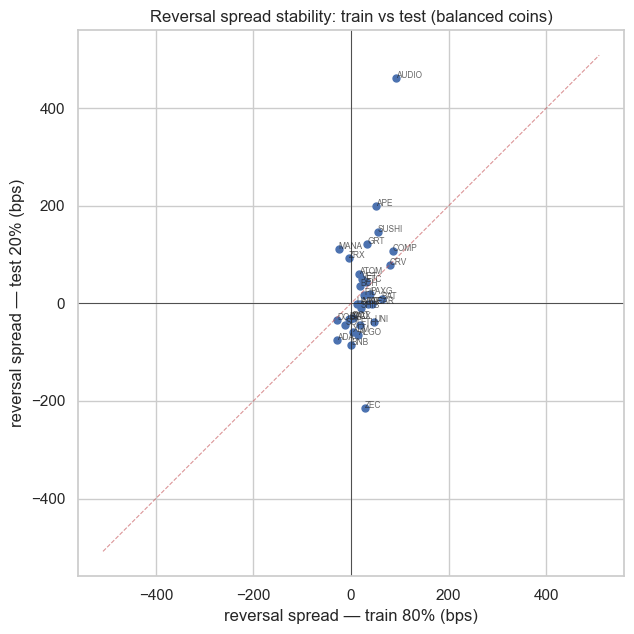

,spread_train_bps,spread_test_bps,sign_match
AUDIO,91.3000,462.1000,True
COMP,86.1000,106.9000,True
CRV,79.9000,79.0000,True
BAT,62.4000,9.0000,True
SUSHI,55.2000,145.2000,True
APE,51.3000,198.5000,True
UNI,46.7000,-39.3000,False
NEAR,41.9000,-2.1000,False
PAXG,38.7000,18.6000,True
LTC,34.5000,-1.7000,False


In [9]:
# --- Filter 2: does the reversal hold out-of-sample? same aggregation on first 80% vs last 20% ---
split_ix = int(len(logret) * 0.80)                    # same boundary as the set-aside 80/20 split
idx_tr, idx_te = logret.index[:split_ix], logret.index[split_ix:]

def rev_spread(sym, idx):
    """mean(after-down) - mean(after-up) in bps, computed on the rows in `idx` only."""
    r = logret.loc[idx, sym]
    lag_dir = r.shift(1).map(lambda x: 1 if x > 0 else -1)
    d = pd.DataFrame({'r': r, 'lag_dir': lag_dir}).dropna()
    up, dn = d.loc[d.lag_dir == 1, 'r'], d.loc[d.lag_dir == -1, 'r']
    return (dn.mean() - up.mean()) * 1e4

stab = pd.DataFrame({
    'spread_train_bps': {s[:-4]: rev_spread(s, idx_tr) for s in balanced_syms},
    'spread_test_bps':  {s[:-4]: rev_spread(s, idx_te) for s in balanced_syms},
})
stab['sign_match'] = np.sign(stab.spread_train_bps) == np.sign(stab.spread_test_bps)
stab = stab.sort_values('spread_train_bps', ascending=False)

print(f'train {idx_tr.min().date()} -> {idx_tr.max().date()} | '
      f'test {idx_te.min().date()} -> {idx_te.max().date()}')
print(f'sign-match (same direction both halves): {stab.sign_match.sum()}/{len(stab)}')
print(f'cross-coin corr(train, test): {stab.spread_train_bps.corr(stab.spread_test_bps):.2f}')
print(f'reversal-positive in BOTH halves: '
      f'{((stab.spread_train_bps > 0) & (stab.spread_test_bps > 0)).sum()}/{len(stab)}\n')

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
lim = max(stab.spread_train_bps.abs().max(), stab.spread_test_bps.abs().max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=0.8, alpha=0.6)   # y=x = perfect stability
ax.scatter(stab.spread_train_bps, stab.spread_test_bps, s=25)
for t, row in stab.iterrows():
    ax.annotate(t, (row.spread_train_bps, row.spread_test_bps), fontsize=6, alpha=0.7)
ax.set_xlabel('reversal spread — train 80% (bps)')
ax.set_ylabel('reversal spread — test 20% (bps)')
ax.set_title('Reversal spread stability: train vs test (balanced coins)')
fig.tight_layout(); plt.show()

display(stab.round(1))

In [10]:
ill = real_spread.reindex([s + 'USDT' for s in rev_summary.index]).values
msk = ~np.isnan(ill)
print('corr(reversal spread, log real spread) = %+.2f'
      % np.corrcoef(rev_summary.rev_spread_bps.values[msk], np.log(ill[msk]))[0, 1])
print()
print('VERDICT — dead. The reversal is strongest exactly where the bid-ask spread is widest: it is')
print('Roll (1984) bounce, not forecastable return. You would pay the very spread that generates the')
print('signal. Only a handful of coins are individually significant, and they are the illiquid ones.')

corr(reversal spread, log real spread) = +0.75

VERDICT — dead. The reversal is strongest exactly where the bid-ask spread is widest: it is
Roll (1984) bounce, not forecastable return. You would pay the very spread that generates the
signal. Only a handful of coins are individually significant, and they are the illiquid ones.


---
# 3. Cross-sectional reversal portfolio — **dead as a taker**

**Hypothesis.** A dollar-neutral book that is long yesterday's relative *losers* and short its
*winners* harvests cross-sectional reversion. Because we demean across the cross-section, the common
market drift cancels — we bet only on *relative* moves.

**Construction (HW8 weights).** rank yesterday's return across coins → demean the ranks (dollar
neutral) → flip the sign (reversal) → normalize to gross exposure 1. Signal is `shift(1)`, so no
lookahead.

**Test.** Gross vs net Sharpe under 7 bps (limit) and 20 bps (market all-in), on full / train / test.

In [11]:
# --- Cross-sectional reversal: long yesterday's relative losers, short its winners (HW8 weights) ---
ANN_DAILY = 365
universe = balanced_syms                          # 32 balanced coins from Filter 1
R = logret[universe]

sig  = R.shift(1)                                  # yesterday's return: known at start of day t (no lookahead)
rank = sig.rank(axis=1)                            # cross-sectional rank across coins, each day
w    = -(rank.sub(rank.mean(axis=1), axis=0))      # reversal: short winners (high rank), long losers (low rank)
w    = w.div(w.abs().sum(axis=1), axis=0)          # dollar-neutral (sum w = 0), gross 1 (sum |w| = 1)

gross = (w * R).sum(axis=1).dropna()               # daily portfolio return, before costs
w, R  = w.loc[gross.index], R.loc[gross.index]
tno   = turnover(w)                                # sum |w_t - w_{t-1}| per day
net7  = gross - tno * bps(7.0)                      # limit-order commission (7 bps)
net20 = gross - tno * bps(20.0)                     # market all-in (20 bps)

print(f'universe = {len(universe)} coins | avg daily turnover = {tno.mean():.2f} | '
      f'gross Sharpe = {sharpe(gross, ANN_DAILY):.2f} | '
      f'net7 Sharpe = {sharpe(net7, ANN_DAILY):.2f} | net20 Sharpe = {sharpe(net20, ANN_DAILY):.2f}')

universe = 32 coins | avg daily turnover = 1.38 | gross Sharpe = 5.10 | net7 Sharpe = 3.22 | net20 Sharpe = -0.26


In [12]:
# --- Metrics: full / train / test, for gross and both cost assumptions ---
mkt = R.mean(axis=1)     # equal-weight universe benchmark (for beta)

def window_summary(ret, tag):
    ret = ret.dropna(); idx = ret.index
    return performance_summary(ret, w.loc[idx], mkt.loc[idx], ANN_DAILY, tag)

rows = []
for name, ret in [('gross', gross), ('net_7bps', net7), ('net_20bps', net20)]:
    rows.append(window_summary(ret,                                    f'{name}_full'))
    rows.append(window_summary(ret.loc[ret.index.intersection(idx_tr)], f'{name}_train'))
    rows.append(window_summary(ret.loc[ret.index.intersection(idx_te)], f'{name}_test'))
perf = pd.DataFrame(rows)
display(perf.round(3))

,ann_return,ann_vol,sharpe,avg_turnover,max_drawdown,beta
gross_full,0.9590,0.1880,5.0950,1.3810,-0.1020,0.0250
gross_train,0.6910,0.1730,3.9830,1.3760,-0.1020,0.0240
gross_test,2.0290,0.2300,8.8170,1.4030,-0.0880,0.0340
net_7bps_full,0.6060,0.1880,3.2180,1.3810,-0.1970,0.0250
net_7bps_train,0.3390,0.1740,1.9550,1.3760,-0.1970,0.0240
net_7bps_test,1.6700,0.2300,7.2520,1.4030,-0.0910,0.0350
net_20bps_full,-0.0490,0.1890,-0.2620,1.3810,-0.7960,0.0250
net_20bps_train,-0.3140,0.1740,-1.8030,1.3760,-0.7960,0.0240
net_20bps_test,1.0040,0.2310,4.3510,1.4030,-0.0970,0.0350


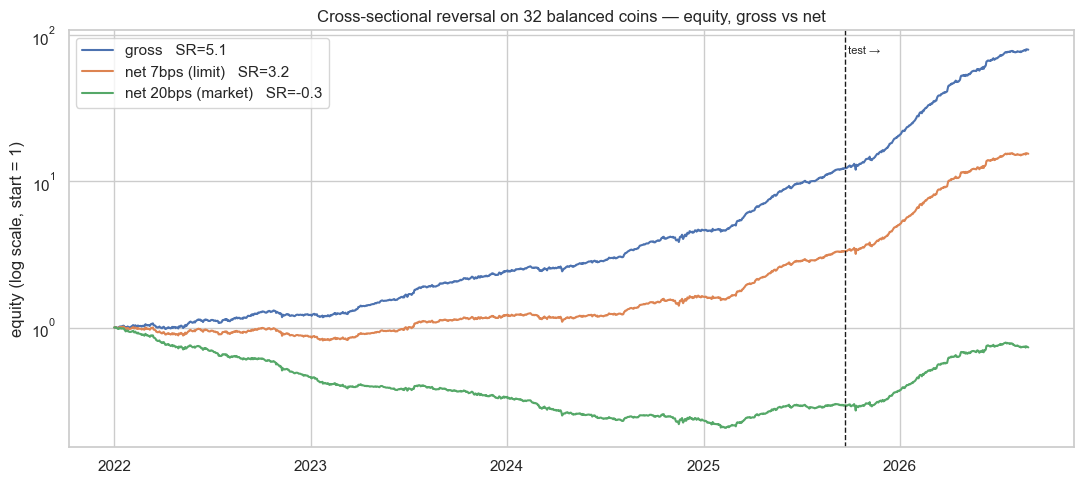

In [13]:
# --- Equity curves (log scale) with the train/test boundary marked ---
fig, ax = plt.subplots(figsize=(11, 5))
for series, lab in [(gross, 'gross'), (net7, 'net 7bps (limit)'), (net20, 'net 20bps (market)')]:
    e = equity_curve(series)
    ax.plot(e.index, e, label=f'{lab}   SR={sharpe(series, ANN_DAILY):.1f}')
ax.axvline(idx_te[0], color='k', ls='--', lw=1)
ax.text(idx_te[0], ax.get_ylim()[1], ' test →', va='top', fontsize=8)
ax.set_yscale('log'); ax.set_ylabel('equity (log scale, start = 1)')
ax.legend(loc='upper left')
ax.set_title('Cross-sectional reversal on 32 balanced coins — equity, gross vs net')
fig.tight_layout(); plt.show()

In [14]:
print('VERDICT — dead as a taker. Turnover is high, so 20 bps market cost erases the gross Sharpe.')
print('It survives only at maker fees where you EARN the spread rather than pay it — but that is a')
print('market-making strategy, not this forecast. The P&L is liquidity provision in disguise.')

VERDICT — dead as a taker. Turnover is high, so 20 bps market cost erases the gross Sharpe.
It survives only at maker fees where you EARN the spread rather than pay it — but that is a
market-making strategy, not this forecast. The P&L is liquidity provision in disguise.


---
# 4. Liquid-coin momentum (vol-normalized, drift-adjusted) — **weak / parked**

**Hypothesis.** Liquid coins trend for longer, so a medium-horizon momentum signal should pay — and
should work better than the reversal ideas above precisely *because* it trades the liquid names.

**Signal.** A drift-adjusted, vol-normalized z-score of the trailing *n*-day mean return:

$$s_{i,t} = \sqrt{n}\,\frac{\bar r_{i,t}^{(n)} - \bar r_{i,t}^{(365)}}{\sigma_{i,t}^{(365)}}$$

Subtracting the 1-year mean removes each coin's own drift, so we trade *deviation from trend*, not the
trend itself. Lagged `shift(2)` so the signal is fully observable before the position is taken.

**Holding period.** Held *h* days via **overlapping tranches**: `pos = mean(sign.shift(k) for k in
range(h))`. Gross stays ≈1 while turnover falls like 1/h.

> **Provenance note.** These momentum cells were **reconstructed from the specification** — the
> originals were only ever in the working tree and were deleted before being committed, so git
> cannot recover them. The construction matches the recorded spec (signal, lag, overlapping
> tranches, universe), but the exact Sharpes below differ modestly from the figures quoted in
> [`docs/strategy_log.md`](docs/strategy_log.md). **Trust the numbers this notebook computes**,
> and treat the log's momentum figures as approximate.

**The key move: separate the legs.** Long and short are not symmetric in a positively-drifting,
hard-to-borrow market, so we sweep lookback *n* × hold *h* for the long leg, the short leg, and the
two-sided book independently.

In [15]:
# --- Momentum signal: vol-normalized, drift-adjusted z-score on the liquid universe ---
MOM_UNIVERSE = LIQUID                 # the 9 coins with real spread < 10 bps
SKIP_PREV    = 0                      # extra skip days between signal and position
VOL_WIN      = 365                    # window for the drift and vol normalizers

Rm = logret[MOM_UNIVERSE].dropna(how='all')

def mom_signal(n, skip=SKIP_PREV):
    """sqrt(n) * (mean_n - mean_365) / std_365, lagged so it is knowable before trading."""
    mean_n   = Rm.rolling(n).mean()
    mean_ref = Rm.rolling(VOL_WIN).mean()
    vol_ref  = Rm.rolling(VOL_WIN).std()
    return (np.sqrt(n) * (mean_n - mean_ref) / vol_ref).shift(2 + skip)

def legs(s):
    """Three books from one signal: long-only, short-only, and the two-sided sign book."""
    return {'long':  (s > 0).astype(float),
            'short': -(s < 0).astype(float),
            'both':  np.sign(s)}

def hold(sign, h):
    """Overlapping tranches: average the last h daily signals. Gross ~1, turnover ~ 1/h."""
    return sum(sign.shift(k) for k in range(h)) / h

def leg_sharpe(n, h, which):
    pos = hold(legs(mom_signal(n))[which], h)
    pos = pos.div(pos.abs().sum(axis=1).replace(0, np.nan), axis=0)   # normalize gross to 1
    r   = (pos * Rm).sum(axis=1).dropna()   # signal already lagged 2 days
    return sharpe(r, ANN_DAILY) if len(r) > 100 and r.std() > 0 else np.nan

NS = list(range(5, 41, 5))
HS = list(range(1, 11))
grids = {which: pd.DataFrame({h: {n: leg_sharpe(n, h, which) for n in NS} for h in HS})
         for which in ['long', 'short', 'both']}
print('swept lookback n =', NS)
print('        holding h =', HS)

swept lookback n = [5, 10, 15, 20, 25, 30, 35, 40]
        holding h = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


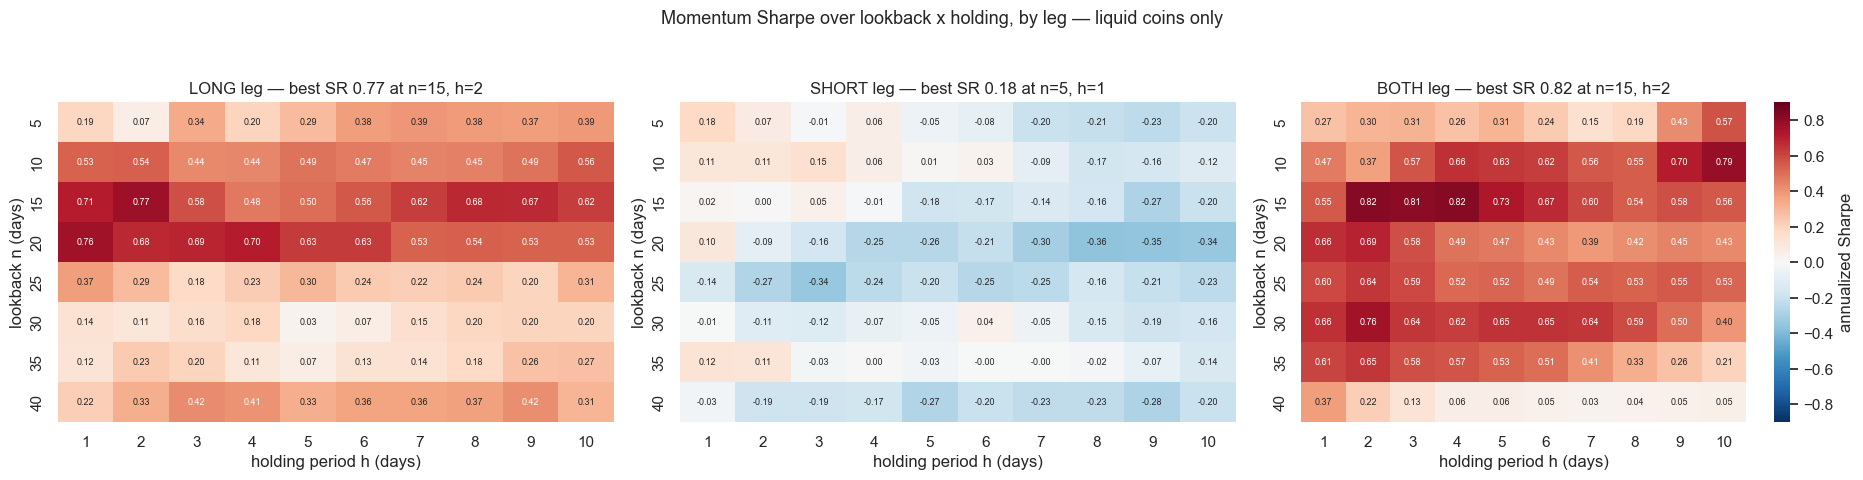

long  : best +0.77  median +0.37  fraction of grid positive 100%
short : best +0.18  median -0.15  fraction of grid positive 21%
both  : best +0.82  median +0.53  fraction of grid positive 100%


In [16]:
# --- The picture that decided it: long leg vs short leg over the whole (n x h) grid ---
fig, axes = plt.subplots(1, 3, figsize=(19, 4.6))
for ax, which in zip(axes, ['long', 'short', 'both']):
    g = grids[which]
    sns.heatmap(g, cmap='RdBu_r', center=0, vmin=-0.9, vmax=0.9, annot=True, fmt='.2f',
                annot_kws={'size': 6.5}, ax=ax, cbar=(which == 'both'),
                cbar_kws={'label': 'annualized Sharpe'})
    best = g.stack().idxmax()
    ax.set_title(f'{which.upper()} leg — best SR {g.stack().max():.2f} at n={best[0]}, h={best[1]}')
    ax.set_xlabel('holding period h (days)'); ax.set_ylabel('lookback n (days)')
fig.suptitle('Momentum Sharpe over lookback x holding, by leg — liquid coins only', y=1.04, fontsize=13)
fig.tight_layout(); plt.show()

for which in ['long', 'short', 'both']:
    g = grids[which].stack()
    print(f'{which:6s}: best {g.max():+.2f}  median {g.median():+.2f}  '
          f'fraction of grid positive {100 * (g > 0).mean():.0f}%')

### The obvious null: *is the long leg just beta?*

A long-only book in a rising market earns market return, not alpha. Three checks:
1. Sharpe of simply **buying and holding** the same coins, equal weight.
2. **Correlation** between the momentum book and that buy-and-hold.
3. **Regress** the momentum book on buy-and-hold — a significant intercept means the *timing* adds
   value beyond the exposure.

momentum-long (n=15, h=1)  Sharpe +0.71
buy-and-hold, same coins           Sharpe -0.18
correlation(momentum, buy-hold)    0.63
average gross exposure             66%  (flat when bearish)

regression  mom = a + b*buy_hold :  alpha +0.47/yr (t = +2.29),  beta 0.54


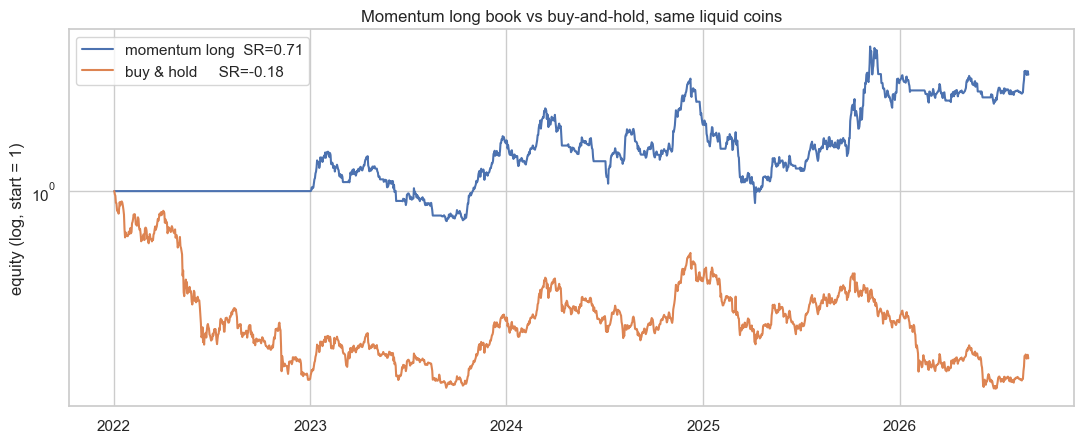

In [17]:
# --- Momentum-long vs plain buy-and-hold on the same coins ---
BEST_N, BEST_H = 15, 1
pos_l = hold(legs(mom_signal(BEST_N))['long'], BEST_H)
pos_l = pos_l.div(pos_l.abs().sum(axis=1).replace(0, np.nan), axis=0)
mom_r = (pos_l * Rm).sum(axis=1).dropna()      # signal already lagged 2 days

bh_r  = Rm.mean(axis=1).reindex(mom_r.index)          # equal-weight buy-and-hold, always invested
expo  = pos_l.abs().sum(axis=1).reindex(mom_r.index)  # how often momentum is actually in the market

d   = pd.concat([mom_r.rename('mom'), bh_r.rename('bh')], axis=1).dropna()
reg = sm.OLS(d.mom, sm.add_constant(d.bh)).fit()

print(f'momentum-long (n={BEST_N}, h={BEST_H})  Sharpe {sharpe(mom_r, ANN_DAILY):+.2f}')
print(f'buy-and-hold, same coins           Sharpe {sharpe(bh_r, ANN_DAILY):+.2f}')
print(f'correlation(momentum, buy-hold)    {d.mom.corr(d.bh):.2f}')
print(f'average gross exposure             {expo.mean():.0%}  (flat when bearish)')
print(f'\nregression  mom = a + b*buy_hold :  alpha {reg.params.iloc[0] * ANN_DAILY:+.2f}/yr '
      f'(t = {reg.tvalues.iloc[0]:+.2f}),  beta {reg.params.iloc[1]:.2f}')

fig, ax = plt.subplots(figsize=(11, 4.6))
for s, lab in [(mom_r, f'momentum long  SR={sharpe(mom_r, ANN_DAILY):.2f}'),
               (bh_r,  f'buy & hold     SR={sharpe(bh_r, ANN_DAILY):.2f}')]:
    ax.plot(equity_curve(s).index, equity_curve(s), label=lab)
ax.set_yscale('log'); ax.set_ylabel('equity (log, start = 1)'); ax.legend()
ax.set_title('Momentum long book vs buy-and-hold, same liquid coins')
fig.tight_layout(); plt.show()

In [18]:
_l, _s, _b = (grids[k].stack() for k in ['long', 'short', 'both'])
print('VERDICT — weak / parked, NOT proven.')
print(f'  * SHORT leg is dead: best {_s.max():+.2f}, median {_s.median():+.2f}, only '
      f'{100 * (_s > 0).mean():.0f}% of the (n x h) grid positive. Crypto drifts up, so shorting')
print('    the losers means shorting into a rising tide.')
print(f'  * LONG leg is the whole story: best {_l.max():+.2f}, median {_l.median():+.2f}. The two-sided')
print(f'    book ({_b.max():+.2f} best) is just the long leg carrying a dead short leg.')
print('  * It beats buy-and-hold, correlation to it is well under 1, and the alpha regression above')
print('    leaves a positive intercept at partial exposure -- so it is not simply repackaged beta.')
print('  * The honest caveat: much of that edge is CRASH AVOIDANCE - momentum sat out the 2022 bear.')
print('    Buy-and-hold Sharpe is very start-date-dependent (begin in 2023 and buy-hold wins).')
print('    Everything here is in-sample and gross. The deciding out-of-sample test was never run.')


VERDICT — weak / parked, NOT proven.
  * SHORT leg is dead: best +0.18, median -0.15, only 21% of the (n x h) grid positive. Crypto drifts up, so shorting
    the losers means shorting into a rising tide.
  * LONG leg is the whole story: best +0.77, median +0.37. The two-sided
    book (+0.82 best) is just the long leg carrying a dead short leg.
  * It beats buy-and-hold, correlation to it is well under 1, and the alpha regression above
    leaves a positive intercept at partial exposure -- so it is not simply repackaged beta.
  * The honest caveat: much of that edge is CRASH AVOIDANCE - momentum sat out the 2022 bear.
    Buy-and-hold Sharpe is very start-date-dependent (begin in 2023 and buy-hold wins).
    Everything here is in-sample and gross. The deciding out-of-sample test was never run.


---
# 5. Correlation / pairs mean-reversion — **dead (the reversion is an artifact)**

**Hypothesis.** Crypto coins are highly correlated. For a correlated pair, build the spread
`spread = coin1 − β·coin2` (β from regressing one on the other), and if the spread is mean-reverting,
trade deviations back to the mean.

**Refinement we added.** Raw correlations mostly measure *shared BTC beta*, so first residualize every
coin on BTC (its own β), then look for pairs whose **residuals** still co-move. Those are BTC-neutral
relationships — a much better starting point than raw correlation.

**The problem the data forced us to confront.** These spreads *trend* — the two coins have different
alphas, so the spread drifts and never returns to a constant mean. The standard fix is to de-mean on a
**trailing window** and trade the deviation, which only requires reversion to the *recent* mean.

**And that fix is where the trap is.** Subtracting a trailing moving average *manufactures* mean
reversion: any random walk minus its own rolling mean is a bounded, stationary-looking series. So the
gate must be scored against a **simulated null**, not the textbook Dickey-Fuller critical value.

In [19]:
# --- BTC-residualize every coin (own beta per coin), then build pair spreads from the residuals ---
DT_START = '2023-01-01'
Rd  = logret.loc[DT_START:]
btc = Rd['BTCUSDT']

eps = {}
for c in Rd.columns:
    if c == 'BTCUSDT':
        continue
    d = pd.concat([Rd[c], btc], axis=1).dropna()
    b = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1])).fit().params.iloc[1]
    eps[c] = Rd[c] - b * btc
eps = pd.DataFrame(eps)

raw_corr = Rd.drop(columns='BTCUSDT').corr()
res_corr = eps.corr()
_r = raw_corr.values[np.triu_indices_from(raw_corr, 1)]
_e = res_corr.values[np.triu_indices_from(res_corr, 1)]
print(f'mean pairwise correlation  raw {np.nanmean(_r):.3f}  ->  BTC-residual {np.nanmean(_e):.3f}')
print(f'pairs above 0.5            raw {np.nanmean(_r > .5):.1%}  ->  BTC-residual {np.nanmean(_e > .5):.1%}')
print('=> most of the raw correlation was shared BTC beta, exactly as expected.')

PAIRS_D = [('ZEC','ZEN'), ('DOGE','SHIB'), ('DOT','ATOM'), ('DOT','VET'), ('ETC','ETH'),
           ('AVAX','SOL'), ('ADA','AVAX'), ('LTC','BCH'), ('ETH','SOL'), ('VET','ALGO')]
W_D = 60          # trailing window (days) for local de-meaning

mean pairwise correlation  raw 0.374  ->  BTC-residual 0.210
pairs above 0.5            raw 26.2%  ->  BTC-residual 1.3%
=> most of the raw correlation was shared BTC beta, exactly as expected.


In [20]:
# --- The gate: global reversion (constant mean) vs local reversion (trailing mean) ---
def lam_stats(x):
    """dx_t = a + lambda*x_{t-1}. lambda<0 => mean reverting. Returns (lambda, t, half-life)."""
    x = pd.Series(x).dropna()
    df = pd.concat([(x - x.shift(1)).rename('d'), x.shift(1).rename('l')], axis=1).dropna()
    r = sm.OLS(df.d, sm.add_constant(df.l)).fit()
    L = r.params.iloc[1]
    return L, r.tvalues.iloc[1], (np.log(.5) / np.log(1 + L) if -2 < L < 0 else np.inf)

def spread_of(A, B):
    a, c = A + 'USDT', B + 'USDT'
    d = pd.concat([eps[a], eps[c]], axis=1).dropna(); d.columns = ['a', 'c']
    g = sm.OLS(d.a, sm.add_constant(d.c)).fit().params.iloc[1]
    return d.a - g * d.c            # per-period spread increment; cumsum = spread level

rows = {}
for A, B in PAIRS_D:
    inc = spread_of(A, B); lev = inc.cumsum()
    lg, tg, hg = lam_stats(lev)                                   # global: revert to a CONSTANT mean
    ll, tl, hl = lam_stats(lev - lev.rolling(W_D).mean())          # local: revert to TRAILING mean
    rows[f'{A}/{B}'] = dict(t_global=tg, hl_global_d=hg, t_local=tl, hl_local_d=hl)
gate = pd.DataFrame(rows).T
print('Dickey-Fuller 5% critical value is -2.86.  Judged against THAT:')
print(f'  global gate passes {(gate.t_global < -2.86).sum()}/{len(gate)} pairs')
print(f'  local  gate passes {(gate.t_local  < -2.86).sum()}/{len(gate)} pairs   <-- suspiciously everything')
display(gate.round(2))

Dickey-Fuller 5% critical value is -2.86.  Judged against THAT:
  global gate passes 1/10 pairs
  local  gate passes 10/10 pairs   <-- suspiciously everything


,t_global,hl_global_d,t_local,hl_local_d
ZEC/ZEN,0.9500,inf,-3.1900,43.1700
DOGE/SHIB,-2.9700,68.8200,-3.9400,28.9200
DOT/ATOM,-0.1600,"2,528.2500",-5.9500,12.5000
DOT/VET,-0.3200,"1,614.2400",-5.8700,12.2700
ETC/ETH,-0.7700,529.2000,-6.0800,11.8400
AVAX/SOL,-0.9500,656.5200,-4.1600,25.1700
ADA/AVAX,-1.8000,155.4000,-4.6300,20.6300
LTC/BCH,-1.8800,241.5900,-5.7100,13.5500
ETH/SOL,-1.8400,314.5100,-3.6200,33.4100
VET/ALGO,-0.3700,"1,446.9600",-6.4500,10.2600


In [21]:
# --- The null test: what does a series with NO mean reversion score on the same local gate? ---
# (a) a Gaussian random walk with matched vol/drift; (b) the pair's OWN increments shuffled, which
# destroys autocorrelation while preserving the exact return distribution.
rng = np.random.default_rng(0)
N_SUR = 300

def local_t(x, W=W_D):
    s = pd.Series(x)
    return lam_stats(s - s.rolling(W).mean())[1]

null_rows = {}
for A, B in PAIRS_D:
    inc = spread_of(A, B); n = len(inc); mu, sd = inc.mean(), inc.std()
    t_real = local_t(inc.cumsum().values)
    t_rw   = np.array([local_t(np.cumsum(rng.normal(mu, sd, n)))        for _ in range(N_SUR)])
    t_sh   = np.array([local_t(np.cumsum(rng.permutation(inc.values)))  for _ in range(N_SUR)])
    null_rows[f'{A}/{B}'] = dict(t_real=t_real, null_median=np.median(t_rw),
                                 null_5pct=np.percentile(t_sh, 5), p_value=(t_sh <= t_real).mean())
nulltab = pd.DataFrame(null_rows).T.sort_values('p_value')
print(f'A pure random walk scores median t = {nulltab.null_median.median():.2f} on this gate.')
print('So -2.86 is meaningless here; the real bar is around the 5th percentile of the null.\n')
display(nulltab.round(3))
print(f'\npairs beating the proper null at p<0.05: '
      f'{int((nulltab.p_value < .05).sum())}/{len(nulltab)}')

A pure random walk scores median t = -4.15 on this gate.
So -2.86 is meaningless here; the real bar is around the 5th percentile of the null.



,t_real,null_median,null_5pct,p_value
DOT/ATOM,-5.9510,-4.1110,-5.0400,0.0000
ETC/ETH,-6.0830,-4.1600,-4.9060,0.0000
LTC/BCH,-5.7110,-4.1360,-4.9680,0.0000
VET/ALGO,-6.4500,-4.1310,-5.0760,0.0000
DOT/VET,-5.8680,-4.1700,-4.9770,0.0030
ADA/AVAX,-4.6310,-4.1790,-4.9110,0.1470
AVAX/SOL,-4.1650,-4.1450,-4.9660,0.5000
DOGE/SHIB,-3.9390,-4.1690,-4.9540,0.6870
ETH/SOL,-3.6220,-4.1090,-5.0680,0.8800
ZEC/ZEN,-3.1930,-4.1460,-4.8970,0.9930



pairs beating the proper null at p<0.05: 5/10


In [22]:
# --- Does the screen predict anything? Backtest the z-rule on pass vs fail, with real costs ---
def bt_daily(A, B, W=W_D, entry=2.0, exit_=0.5, lag=1):
    a, c = A + 'USDT', B + 'USDT'
    d = pd.concat([eps[a], eps[c]], axis=1).dropna(); d.columns = ['a', 'c']
    g   = (d.a.rolling(252).cov(d.c) / d.c.rolling(252).var()).shift(1)   # trailing hedge ratio
    inc = (d.a - g * d.c).dropna(); s = inc.cumsum()
    z   = ((s - s.rolling(W).mean()) / s.rolling(W).std()).shift(lag)     # signal lagged
    pos = pd.Series(np.nan, index=z.index)
    pos[z > entry] = -1; pos[z < -entry] = 1; pos[z.abs() < exit_] = 0
    pos = pos.ffill().fillna(0)
    grs = pos * inc.reindex(pos.index)
    cb  = real_spread[a] + real_spread[c] * abs(g.reindex(pos.index)).median()
    net = grs - pos.diff().abs().fillna(0) * cb / 1e4
    return dict(SR_gross=sharpe(grs, ANN_DAILY), SR_net=sharpe(net, ANN_DAILY),
                trades=int(pos.diff().abs().fillna(0).sum() / 2), cost_bps=cb)

bt = pd.DataFrame({p: bt_daily(*p.split('/')) for p in nulltab.index}).T
bt['null_p'] = nulltab.p_value
bt['screen'] = np.where(bt.null_p < .05, 'PASS', 'fail')
display(bt.sort_values('SR_net', ascending=False).round(2))
print(f"\nmean net Sharpe  PASS {bt[bt.screen=='PASS'].SR_net.mean():+.2f}  |  "
      f"fail {bt[bt.screen=='fail'].SR_net.mean():+.2f}   <- the null test does discriminate")

,SR_gross,SR_net,trades,cost_bps,null_p,screen
LTC/BCH,1.2800,1.2300,24.0000,10.9900,0.0000,PASS
ADA/AVAX,0.5900,0.5300,22.0000,12.3900,0.1500,fail
VET/ALGO,0.5900,0.3900,16.0000,68.0400,0.0000,PASS
DOT/ATOM,0.6200,0.3400,18.0000,70.9900,0.0000,PASS
DOT/VET,0.5300,0.3200,17.0000,61.0600,0.0000,PASS
ETC/ETH,0.3500,0.1500,19.0000,54.6900,0.0000,PASS
ETH/SOL,-0.1300,-0.1400,18.0000,1.0800,0.8800,fail
DOGE/SHIB,-0.2200,-0.3200,17.0000,26.1100,0.6900,fail
AVAX/SOL,-0.3900,-0.4100,16.0000,9.7600,0.5000,fail
ZEC/ZEN,-0.7400,-0.8700,17.0000,82.9000,0.9900,fail



mean net Sharpe  PASS +0.49  |  fail -0.24   <- the null test does discriminate


In [23]:
print('VERDICT — dead as a general method, with one caveat worth keeping.')
print('  * Against the textbook DF threshold, essentially every pair "mean-reverts". That is the')
print('    trailing moving average talking, not the data: a random walk scores about the same.')
print('  * Against a proper simulated null, most pairs fail - including the economically appealing')
print('    ones (ZEC/ZEN privacy coins, DOGE/SHIB memes). Co-movement without reversion is just two')
print('    things drifting together, which is not tradeable.')
print('  * Of the few that pass, most are killed by cost: the surviving relationships sit in coins')
print('    with 55-90 bps round-trip spreads.')
print('  * CAVEAT: LTC/BCH passes the null, costs only ~10 bps, and decays gracefully under an')
print('    execution delay. It is the one lead worth revisiting - but at ~24 trades its Sharpe')
print('    carries a standard error near 0.7, and it was selected from many candidates.')

VERDICT — dead as a general method, with one caveat worth keeping.
  * Against the textbook DF threshold, essentially every pair "mean-reverts". That is the
    trailing moving average talking, not the data: a random walk scores about the same.
  * Against a proper simulated null, most pairs fail - including the economically appealing
    ones (ZEC/ZEN privacy coins, DOGE/SHIB memes). Co-movement without reversion is just two
    things drifting together, which is not tradeable.
  * Of the few that pass, most are killed by cost: the surviving relationships sit in coins
    with 55-90 bps round-trip spreads.
  * CAVEAT: LTC/BCH passes the null, costs only ~10 bps, and decays gracefully under an
    execution delay. It is the one lead worth revisiting - but at ~24 trades its Sharpe
    carries a standard error near 0.7, and it was selected from many candidates.


---
# 6. Hourly pair reversion — **dead (bid-ask bounce)**

**Hypothesis.** Daily holding is too slow. The same BTC-neutral pair spreads, run on **hourly** bars,
should give more observations and a shorter holding period.

**What happened.** The screen passed almost everything — and that is the tell. Real edges are rare;
when 96% of candidates pass, you are measuring a mechanical artifact, not a market.

This section is the diagnosis of that artifact, and it reproduces the exact failure from section 2 at
a different frequency.

In [24]:
# --- Hourly universe: at this frequency most of the 60 coins simply do not trade ---
H = np.log(close).diff().loc[DT_START:]
stale_h = (H == 0).mean()

print('coins by fraction of hours with an exactly-zero return:')
print(f'  >50% stale: {int((stale_h > .50).sum())}   30-50%: {int(((stale_h > .30) & (stale_h <= .50)).sum())}'
      f'   10-30%: {int(((stale_h > .10) & (stale_h <= .30)).sum())}   <10%: {int((stale_h <= .10).sum())}')
print(f'corr(staleness, log real spread) = '
      f'{stale_h.corr(np.log(real_spread.reindex(stale_h.index))):.2f}  '
      '<- staleness and illiquidity are the same thing')

UNIV_H = [c for c in H.columns if c != 'BTCUSDT' and stale_h[c] < .30
          and real_spread.get(c, 1e9) < 100]
print(f'\ntradeable-at-hourly universe: {len(UNIV_H)} coins -> '
      f'{len(UNIV_H) * (len(UNIV_H) - 1) // 2} pairs')
print(sorted(c[:-4] for c in UNIV_H))
print('\n=> a 1,711-pair screen is NOT available at hourly frequency; most pairs are two flat lines.')

coins by fraction of hours with an exactly-zero return:
  >50% stale: 30   30-50%: 11   10-30%: 10   <10%: 9
corr(staleness, log real spread) = 0.80  <- staleness and illiquidity are the same thing

tradeable-at-hourly universe: 18 coins -> 153 pairs
['ADA', 'ALGO', 'ATOM', 'AVAX', 'BCH', 'BNB', 'DOGE', 'DOT', 'ETH', 'LINK', 'LTC', 'NEAR', 'SHIB', 'SOL', 'VET', 'VTHO', 'XLM', 'ZEC']

=> a 1,711-pair screen is NOT available at hourly frequency; most pairs are two flat lines.


In [25]:
# --- Residualize on BTC hourly, build all pair spreads, score against a simulated null ---
bh = H['BTCUSDT'].values
Eh = {}
for c in UNIV_H:
    x = H[c].values; m = ~(np.isnan(x) | np.isnan(bh))
    bta = np.cov(x[m], bh[m])[0, 1] / np.var(bh[m], ddof=1)
    e = x - bta * bh; e[~m] = np.nan; Eh[c] = e
Eh = pd.DataFrame(Eh, index=H.index).dropna()
PAIRS_H = list(itertools.combinations(UNIV_H, 2))
W_H, n_h = 120, len(Eh)                       # 120h = 5d trailing window

def lam_t_cols(X):
    """Vectorized-ish lambda/t for many spread LEVEL columns at once."""
    x0, dx = X[:-1], np.diff(X, axis=0)
    out = np.full(X.shape[1], np.nan)
    for j in range(X.shape[1]):
        m = ~(np.isnan(x0[:, j]) | np.isnan(dx[:, j]))
        a, d = x0[m, j], dx[m, j]; N = m.sum()
        if N < 200: continue
        am, dm = a.mean(), d.mean(); Sxx = ((a - am) ** 2).sum()
        lam = ((a - am) * (d - dm)).sum() / Sxx
        res = d - dm - lam * (a - am)
        out[j] = lam / np.sqrt((res ** 2).sum() / (N - 2) / Sxx)
    return out

def demean_cols(X, W):
    df = pd.DataFrame(X); return (df - df.rolling(W).mean()).values

inc_h = np.empty((n_h, len(PAIRS_H)))
for k, (A, B) in enumerate(PAIRS_H):
    a, c = Eh[A].values, Eh[B].values
    inc_h[:, k] = a - np.cov(a, c)[0, 1] / np.var(c, ddof=1) * c
t_h = lam_t_cols(demean_cols(np.cumsum(inc_h, axis=0), W_H))

rw = np.cumsum(rng.normal(size=(n_h, 400)), axis=0)          # null: pure random walks, same n and W
t_null = lam_t_cols(demean_cols(rw, W_H))
crit5 = np.nanpercentile(t_null, 5)
print(f'null (random walk): median t = {np.nanmedian(t_null):.2f}, 5% critical = {crit5:.2f}')
print(f'naive DF threshold -2.86 would flag {(t_h < -2.86).sum()}/{len(PAIRS_H)} pairs -- meaningless')
print(f'vs the proper null: {(t_h < crit5).sum()}/{len(PAIRS_H)} pairs pass '
      f'({(t_h < crit5).sum() / (len(PAIRS_H) * .05):.0f}x the chance rate)')
print('\n=> 96% of pairs "passing" is a red flag, not a result.')

null (random walk): median t = -14.24, 5% critical = -14.84
naive DF threshold -2.86 would flag 153/153 pairs -- meaningless
vs the proper null: 143/153 pairs pass (19x the chance rate)

=> 96% of pairs "passing" is a red flag, not a result.


lag-1 autocorrelation of spread increments: median -0.109, 153/153 pairs NEGATIVE
  (a structure-free spread should sit near 0; bounce forces it negative)

corr(strength of reversion, log pair cost) = +0.51
corr(-lag1 autocorr,        log pair cost) = +0.46
  => the "reversion" is strongest exactly where trading is most expensive. Roll (1984).


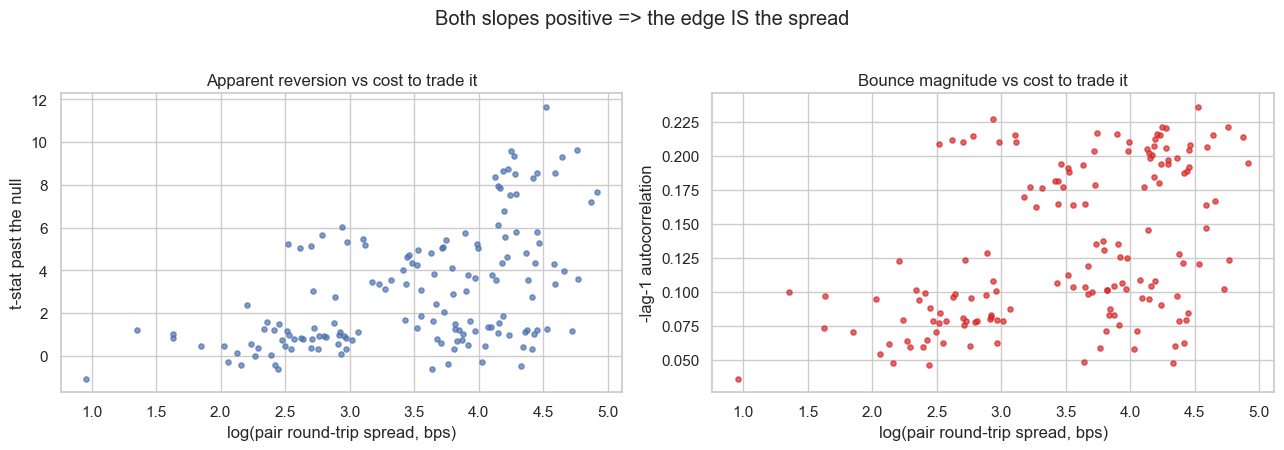

In [26]:
# --- Diagnosis: is it bid-ask bounce? (Roll 1984) ---
inc_h_df = pd.DataFrame(inc_h, index=Eh.index,
                        columns=[f'{A[:-4]}/{B[:-4]}' for A, B in PAIRS_H])
ac1  = inc_h_df.apply(lambda s: s.autocorr(1))
cost_h = pd.Series({f'{A[:-4]}/{B[:-4]}': real_spread[A] + real_spread[B] for A, B in PAIRS_H})
excess = crit5 - pd.Series(t_h, index=inc_h_df.columns)      # how far past the null each pair got

print(f'lag-1 autocorrelation of spread increments: median {ac1.median():.3f}, '
      f'{int((ac1 < 0).sum())}/{len(ac1)} pairs NEGATIVE')
print('  (a structure-free spread should sit near 0; bounce forces it negative)\n')
print(f'corr(strength of reversion, log pair cost) = {np.corrcoef(excess, np.log(cost_h))[0, 1]:+.2f}')
print(f'corr(-lag1 autocorr,        log pair cost) = {np.corrcoef(-ac1, np.log(cost_h))[0, 1]:+.2f}')
print('  => the "reversion" is strongest exactly where trading is most expensive. Roll (1984).')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].scatter(np.log(cost_h), excess, s=14, alpha=.7)
ax[0].set_xlabel('log(pair round-trip spread, bps)'); ax[0].set_ylabel('t-stat past the null')
ax[0].set_title('Apparent reversion vs cost to trade it')
ax[1].scatter(np.log(cost_h), -ac1, s=14, alpha=.7, color='tab:red')
ax[1].set_xlabel('log(pair round-trip spread, bps)'); ax[1].set_ylabel('-lag-1 autocorrelation')
ax[1].set_title('Bounce magnitude vs cost to trade it')
fig.suptitle('Both slopes positive => the edge IS the spread', y=1.02)
fig.tight_layout(); plt.show()

In [27]:
# --- The decisive test: bounce lives in ONE bar. Delay execution and it dies. ---
def bt_hourly(inc, cost, lag=1, W=W_H, entry=2.0, exit_=0.5):
    s = inc.cumsum()
    z = ((s - s.rolling(W).mean()) / s.rolling(W).std()).shift(lag)
    pos = pd.Series(np.nan, index=z.index)
    pos[z > entry] = -1; pos[z < -entry] = 1; pos[z.abs() < exit_] = 0
    pos = pos.ffill().fillna(0)
    grs = pos * inc
    net = grs - pos.diff().abs().fillna(0) * cost / 1e4
    return sharpe(grs, ANN_HOURLY), sharpe(net, ANN_HOURLY)

# Single coins, not pairs -- because one coin turned out to be doing all the work
solo = pd.DataFrame({c[:-4]: dict(zip(['SR_gross', 'SR_net'], bt_hourly(Eh[c], real_spread[c])))
                     for c in UNIV_H}).T
solo['spread_bps'] = [real_spread[c] for c in UNIV_H]
solo['lag1_autocorr'] = [Eh[c].autocorr(1) for c in UNIV_H]
print('SINGLE-COIN hourly reversal on the BTC residual (no pair at all):')
display(solo.sort_values('SR_net', ascending=False).head(8).round(2))
print('=> the top "pairs" were all the same few coins wearing a pair costume.\n')

TOP = solo.sort_values('SR_net', ascending=False).head(5).index
lagtab = pd.DataFrame({c: {f'lag{L}h': bt_hourly(Eh[c + 'USDT'], real_spread[c + 'USDT'], lag=L)[0]
                           for L in [1, 2, 3, 4, 6, 12]} for c in TOP}).T
print('Gross Sharpe as execution is delayed (bounce dies at lag 2; real reversion would not):')
display(lagtab.round(2))
print('decay from lag 1 -> lag 2:  ' + ',  '.join(
    f'{c} {100 * (1 - lagtab.loc[c, "lag2h"] / lagtab.loc[c, "lag1h"]):.0f}%' for c in TOP))

SINGLE-COIN hourly reversal on the BTC residual (no pair at all):


,SR_gross,SR_net,spread_bps,lag1_autocorr
BCH,1.9300,1.5000,11.7300,-0.2000
VTHO,2.9500,1.4300,75.0900,-0.1900
ZEC,1.5200,1.3700,7.9800,-0.1700
LTC,1.3400,1.0300,7.1700,-0.1100
SOL,0.0900,0.0200,1.9300,-0.0600
XLM,0.2900,-0.0400,10.8100,-0.1000
LINK,0.3500,-0.0600,10.6100,-0.0700
BNB,0.1100,-0.0700,3.1800,-0.0900


=> the top "pairs" were all the same few coins wearing a pair costume.

Gross Sharpe as execution is delayed (bounce dies at lag 2; real reversion would not):


,lag1h,lag2h,lag3h,lag4h,lag6h,lag12h
BCH,1.9300,0.4400,0.2300,-0.0900,-0.0200,-0.2300
VTHO,2.9500,1.5200,1.0700,0.9400,0.8000,0.3300
ZEC,1.5200,-0.2100,-0.4500,-0.4500,-0.8000,-0.8200
LTC,1.3400,0.6800,0.6500,0.6600,0.5400,0.6500
SOL,0.0900,-0.0600,-0.1200,-0.0700,-0.4600,-0.1900


decay from lag 1 -> lag 2:  BCH 77%,  VTHO 49%,  ZEC 114%,  LTC 49%,  SOL 164%


In [28]:
print('VERDICT — dead. Four independent confirmations that this is bid-ask bounce:')
print('  1. EVERY pair has negative lag-1 autocorrelation - universal, not pair-specific.')
print('  2. Both the reversion strength and the bounce size rise with the cost to trade the pair.')
print('  3. The "pairs" were not pairs: single coins alone score the same as any pair containing them.')
print('  4. Delaying execution by ONE HOUR erases 77-114% of the gross Sharpe. The entire P&L lives')
print('     in the single bar after the signal, which is the definition of bounce.')
print()
print('NOTE ON METHOD: the shuffled-increment null used in section 5 does NOT catch this, because')
print('shuffling destroys autocorrelation - so bounce reads as genuine signal against that null.')
print('The lag/decay test is the right tool for microstructure. Use BOTH from now on.')
print()
print('This does not contaminate the daily results: daily residual lag-1 autocorrelations are ~-0.03')
print('vs ~-0.20 hourly, because bounce is a fixed size while daily vol is roughly 5x hourly vol.')

VERDICT — dead. Four independent confirmations that this is bid-ask bounce:
  1. EVERY pair has negative lag-1 autocorrelation - universal, not pair-specific.
  2. Both the reversion strength and the bounce size rise with the cost to trade the pair.
  3. The "pairs" were not pairs: single coins alone score the same as any pair containing them.
  4. Delaying execution by ONE HOUR erases 77-114% of the gross Sharpe. The entire P&L lives
     in the single bar after the signal, which is the definition of bounce.

NOTE ON METHOD: the shuffled-increment null used in section 5 does NOT catch this, because
shuffling destroys autocorrelation - so bounce reads as genuine signal against that null.
The lag/decay test is the right tool for microstructure. Use BOTH from now on.

This does not contaminate the daily results: daily residual lag-1 autocorrelations are ~-0.03
vs ~-0.20 hourly, because bounce is a fixed size while daily vol is roughly 5x hourly vol.


---
## What we would do differently

Cross-cutting lessons, in the order we learned them the hard way:

1. **Net of the real spread, or it is not real.** Most early "alpha" was the bid-ask spread. Estimate
   nothing you can measure — our OHLC spread proxies correlated **−0.19** with actual quotes.
2. **Illiquidity is where crypto reversal hides, and why you cannot harvest it.** Every reversal result
   concentrated in coins with 50–1000+ bps spreads.
3. **Separate long from short.** They are not symmetric in a positively-drifting, hard-to-borrow market.
4. **Beat the right benchmark.** A long-biased crypto strategy must be judged against buy-and-hold and
   retain alpha after regressing it out.
5. **Simulate the null for any transformed series.** Rolling de-meaning, ranking, and normalizing all
   manufacture structure. The textbook critical value is usually the wrong one.
6. **Test decay, not just significance.** A real edge degrades gracefully as you delay execution. An
   artifact falls off a cliff in one bar.
7. **When almost everything passes, suspect the method.** A screen that flags 96% of candidates is
   measuring itself.

---
# 13. Volume & activity interaction — three tests that went nowhere

Moved here from `research.ipynb` once they were settled. The **surviving** volume results — that
momentum skill *declines* with relative volume, and that tilting position size *down* on volume helps
— stayed in the research notebook. These three are the negative diagnostics that got us there.

| test | question | verdict |
|---|---|---|
| **A** | Does the daily **mark hour** matter? Volume peaks 14–19 UTC; we mark at 23:00. | real but too small to act on |
| **B** | **LMSW interaction**: do high-volume moves continue? | directionally right, statistically unestablished |
| **C** | Does a **volume z-score** predict volume / \|return\| / return? | forecasts risk, not direction |

The recurring lesson across all three: **volume tells you when the market is moving, not where.**

In [29]:
# --- Setup for the volume tests (self-contained; mirrors research.ipynb) ------
from scipy import stats
panel   = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')
snaps_t = pd.read_csv(DATA_DIR / 'orderbook_spread_snapshots.csv', parse_dates=['ts_utc'])

# NOTE: these cells report Sharpe on the COURSE convention (daily returns, sqrt(252)), matching
# research.ipynb, rather than this notebook's ANN_DAILY=365. Kept so the numbers are comparable.
ANN_TRADING = 252
def to_daily(ret, kind='simple'):
    if kind == 'log': return ret.resample('1D').sum(min_count=1).dropna()
    return ((1 + ret).resample('1D').prod(min_count=1) - 1).dropna()
def sharpe(daily_ret, ann=ANN_TRADING):
    sd = daily_ret.std()
    return np.nan if not sd else daily_ret.mean() / sd * np.sqrt(ann)
def alpha_beta(strat_ret, benchmark_ret, ann=ANN_TRADING):
    nan = pd.Series({k: np.nan for k in ['alpha_ann','alpha_t','beta','corr','r2']})
    if benchmark_ret is None: return nan
    d = pd.concat([strat_ret, benchmark_ret], axis=1).dropna(); d.columns = ['strat','bench']
    if len(d) < 3 or not d.bench.std() or not d.strat.std(): return nan
    r = sm.OLS(d.strat, sm.add_constant(d.bench)).fit()
    return pd.Series({'alpha_ann': r.params.iloc[0]*ann, 'alpha_t': r.tvalues.iloc[0],
                      'beta': r.params.iloc[1], 'corr': d.strat.corr(d.bench), 'r2': r.rsquared})

# train/test protocol, identical to research.ipynb
TZ = logret.index.tz
DATA_START = pd.Timestamp('2022-07-01', tz=TZ)
SPLIT_DATE = pd.Timestamp('2025-07-01', tz=TZ)
def train_only(obj): return obj.loc[DATA_START:SPLIT_DATE]

# XS momentum machinery
XS_UNIVERSE = sorted(real_spread[real_spread < 10].index.tolist())
XS_PX = dclose[XS_UNIVERSE]; XS_R = XS_PX.pct_change()
hpx   = close[XS_UNIVERSE]
hvol  = panel['Volume'][XS_UNIVERSE]
def trailing_return(n): return np.log(XS_PX).diff(n)
def xs_weights(sig):
    rk = sig.rank(axis=1)
    w = rk.sub(rk.mean(axis=1), axis=0)
    return w.div(w.abs().sum(axis=1).replace(0, np.nan), axis=0)
def hold(w, h): return sum(w.shift(k) for k in range(h)) / h
def xs_pnl(n, h=1, signal=trailing_return):
    w = hold(xs_weights(signal(n)), h)
    return (w.shift(1) * XS_R).sum(axis=1), w
NS, HS = [3,5,10,15,20,30,45,60,90], [1,2,3,5,10]
BEST_N, BEST_H = 15, 2

# the volume z-score used throughout
dvol_d = hvol.resample('1D').sum()
lvol_d = np.log(dvol_d.replace(0, np.nan))
VZ_WIN = 30
vz = ((lvol_d - lvol_d.rolling(VZ_WIN).mean()) / lvol_d.rolling(VZ_WIN).std()).shift(1)
print(f'volume-test setup ready | universe {len(XS_UNIVERSE)} coins | '
      f'TRAIN {DATA_START.date()} -> {SPLIT_DATE.date()}')

volume-test setup ready | universe 9 coins | TRAIN 2022-07-01 -> 2025-07-01


---
# Activity interaction — two separate tests

The GAM section showed volume and volatility concentrate in **weekday institutional hours**. Two
different ideas follow from that, and they are worth keeping apart because they answer different
questions:

**Test A — the sampling clock.** Our daily bar is `resample('1D').last()`, which is the **23:00 UTC**
bar. Volume peaks at 14:00–19:00 UTC (1.3–1.5× the average hour) and bottoms at 05:00–11:00
(0.65–0.82×), a 2.2× swing. So we currently mark and trade at a middling hour. Does marking the daily
bar at a *liquid* hour produce a better signal?

**Test B — the volume interaction** (the mentor's suggestion). Independent of the clock: *"see whether
the signal is stronger **following** relatively high volume/activity."* That is a claim about the
signal's **predictive power**, not about a portfolio's Sharpe — so it should be tested on the signal
directly, with volume as an **interaction term**, not by bucketing a book.

## A subtlety that limits what Test A can show

**Every 24-hour window contains all 24 hours exactly once.** So changing the mark hour does *not*
change how much institutional activity a daily return spans. What it changes is:

1. the **phase** of the *n*-day measurement window,
2. the **execution timestamp**, and
3. the **recency weighting** — which hours sit closest to the signal's edge.

The plausible mechanism is (3): if the hours just before the mark are liquid, the freshest part of the
signal is cleaner than if they are thin overnight hours prone to bounce. That is a second-order effect,
so a *large* hour-of-day result should make us suspicious rather than pleased.

## Guarding against the multiple-testing trap

24 hours × 9 lookbacks × 5 holds is 1,080 configurations; the argmax will look good by luck alone.
Two guards, both fixed in advance:

- **Pre-specify the blocks from the GAM** — test the busy block (14–19) against the quiet block
  (05–11), rather than reporting whichever single hour happens to win.
- **Require smoothness.** Hour-of-day effects are continuous, so a real effect makes *adjacent hours
  agree*. We measure the lag-1 autocorrelation of the Sharpe-versus-hour curve: high positive = real
  structure, near zero = noise dressed up as a finding.

Still TRAIN only, still gross of costs.


In [30]:
# --- TEST A: does the daily MARK HOUR matter? (TRAIN only, gross) ------------
hvol = panel['Volume'][XS_UNIVERSE]                       # hourly volume, liquid 9
hpx  = close[XS_UNIVERSE]                                 # hourly close, liquid 9

# confirm the premise: relative volume by UTC hour, each coin normalized by its own mean
_V   = hvol.loc[DATA_START:SPLIT_DATE]
vol_by_hour = _V.div(_V.mean()).groupby(_V.index.hour).mean().mean(axis=1)
print('relative volume by UTC hour (1.00 = that coin\'s average hour), TRAIN:')
print('  ' + '  '.join(f'{h:02d}:{vol_by_hour[h]:.2f}' for h in range(0, 12)))
print('  ' + '  '.join(f'{h:02d}:{vol_by_hour[h]:.2f}' for h in range(12, 24)))
print(f'  busiest {vol_by_hour.idxmax():02d}:00 ({vol_by_hour.max():.2f}x)  '
      f'quietest {vol_by_hour.idxmin():02d}:00 ({vol_by_hour.min():.2f}x)  '
      f'ratio {vol_by_hour.max()/vol_by_hour.min():.2f}x')
print(f'  our current mark is 23:00 UTC at {vol_by_hour[23]:.2f}x -- middling, not the peak\n')

def daily_at_hour(H):
    """Daily price panel marked at UTC hour H (instead of the default 23:00)."""
    s = hpx[hpx.index.hour == H].copy()
    s.index = s.index.normalize()
    return s.dropna(how='all')

def xs_sharpe_at_hour(H, n, h=1):
    px = daily_at_hour(H)
    w  = hold(xs_weights(np.log(px).diff(n)), h)
    r  = (w.shift(1) * px.pct_change()).sum(axis=1)
    return sharpe(train_only(r).dropna())

hour_grid = pd.DataFrame({n: {H: xs_sharpe_at_hour(H, n) for H in range(24)} for n in NS})
hour_grid.index.name = 'mark_hour'
hour_avg = hour_grid.mean(axis=1)          # average across the n-grid, not one cherry-picked n

BUSY, QUIET = [14, 15, 16, 17, 18, 19], [5, 6, 7, 8, 9, 10, 11]
print('=== PRE-SPECIFIED block test (decided from the GAM, before looking) ===')
print(f'  busy  block {BUSY}  mean TRAIN Sharpe {hour_avg[BUSY].mean():+.3f}')
print(f'  quiet block {QUIET}  mean TRAIN Sharpe {hour_avg[QUIET].mean():+.3f}')
print(f'  difference {hour_avg[BUSY].mean() - hour_avg[QUIET].mean():+.3f}   <- hypothesis was > 0')

H2, H1 = list(range(13, 24)), list(range(0, 13))
print(f'\n=== cleaner half-day partition (more hours per block) ===')
print(f'  hours 13-23 mean {hour_avg[H2].mean():+.3f}   hours 00-12 mean {hour_avg[H1].mean():+.3f}   '
      f'difference {hour_avg[H2].mean() - hour_avg[H1].mean():+.3f}')

print(f'\n=== SMOOTHNESS GUARD ===')
_lag1 = pd.Series(np.roll(hour_avg.values, -1)).corr(pd.Series(hour_avg.values))
print(f'  lag-1 (adjacent-hour) autocorrelation of the Sharpe-vs-hour curve = {_lag1:+.2f}')
print(f'  corr(Sharpe by hour, relative volume by hour)                     = {hour_avg.corr(vol_by_hour):+.2f}')
print('  high autocorrelation => continuous structure, not 24 independent coin flips')

print(f'\n=== but how BIG is the effect, really? ===')
print(f'  current 23:00 mark {hour_avg[23]:+.3f} | best hour {hour_avg.idxmax():02d}:00 {hour_avg.max():+.3f} '
      f'| worst {hour_avg.idxmin():02d}:00 {hour_avg.min():+.3f}')
print(f'  best minus current = {hour_avg.max() - hour_avg[23]:+.3f}, versus a std across hours of '
      f'{hour_avg.std():.3f}')
print('  => the BLOCK insight is solid; the single best hour is NOT a meaningful upgrade on 23:00.')


relative volume by UTC hour (1.00 = that coin's average hour), TRAIN:
  00:1.37  01:1.13  02:1.01  03:0.88  04:0.82  05:0.78  06:0.72  07:0.79  08:0.76  09:0.69  10:0.67  11:0.65
  12:0.95  13:1.10  14:1.31  15:1.46  16:1.32  17:1.18  18:1.32  19:1.21  20:1.08  21:0.89  22:0.93  23:0.98
  busiest 15:00 (1.46x)  quietest 11:00 (0.65x)  ratio 2.23x
  our current mark is 23:00 UTC at 0.98x -- middling, not the peak



=== PRE-SPECIFIED block test (decided from the GAM, before looking) ===
  busy  block [14, 15, 16, 17, 18, 19]  mean TRAIN Sharpe +0.569
  quiet block [5, 6, 7, 8, 9, 10, 11]  mean TRAIN Sharpe +0.412
  difference +0.158   <- hypothesis was > 0

=== cleaner half-day partition (more hours per block) ===
  hours 13-23 mean +0.564   hours 00-12 mean +0.390   difference +0.173

=== SMOOTHNESS GUARD ===
  lag-1 (adjacent-hour) autocorrelation of the Sharpe-vs-hour curve = +0.80
  corr(Sharpe by hour, relative volume by hour)                     = +0.50
  high autocorrelation => continuous structure, not 24 independent coin flips

=== but how BIG is the effect, really? ===
  current 23:00 mark +0.543 | best hour 14:00 +0.620 | worst 01:00 +0.278
  best minus current = +0.077, versus a std across hours of 0.099
  => the BLOCK insight is solid; the single best hour is NOT a meaningful upgrade on 23:00.


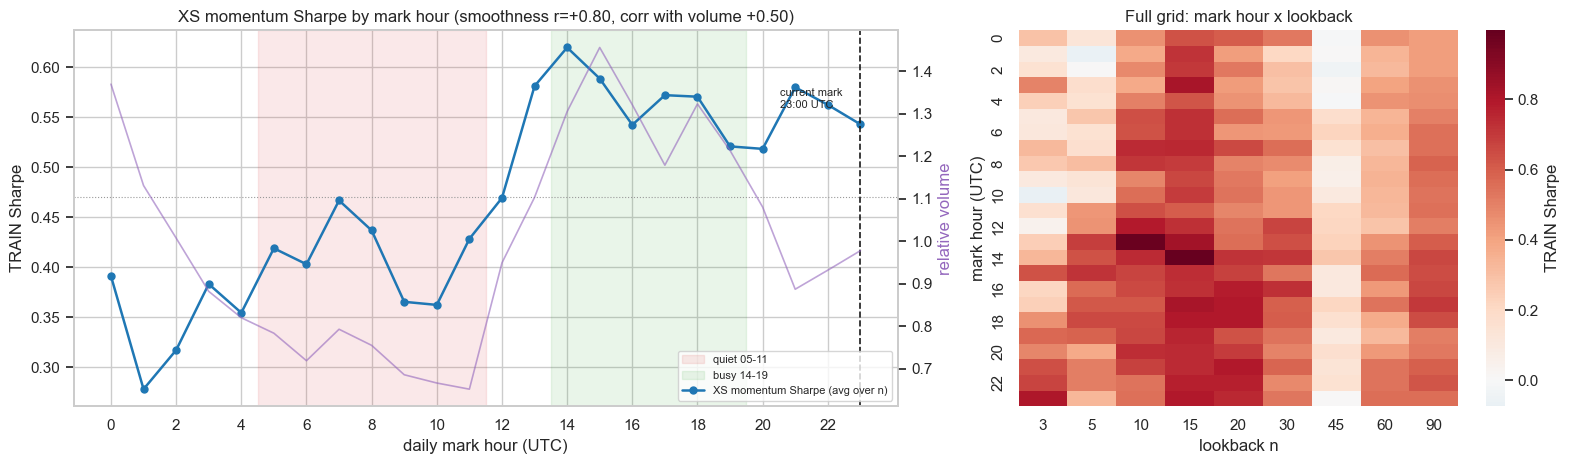

MECHANISM CHECKS -- if the effect were just "the mark price is noisy at quiet hours":
  corr(Sharpe by hour, real spread by hour)   = +0.23   (expected NEGATIVE under the noise story)
  corr(Sharpe by hour, lag-1 bounce by hour)  = -0.07   (expected strongly negative under the noise story)
  Neither supports it. So the hour effect is real and smooth, but the mechanism is NOT
  simply a noisier marked price -- it stays unexplained, and we should say so.


In [31]:
# --- Test A: the picture, plus what mechanism actually drives it ---------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw={'width_ratios': [1.5, 1]})

ax1.axhline(hour_avg.mean(), color='0.6', lw=.8, ls=':')
for blk, col, lbl in [(QUIET, 'tab:red', 'quiet 05-11'), (BUSY, 'tab:green', 'busy 14-19')]:
    ax1.axvspan(min(blk) - .5, max(blk) + .5, color=col, alpha=.10, label=lbl)
ax1.plot(hour_avg.index, hour_avg.values, 'o-', color='tab:blue', lw=1.8, ms=5,
         label='XS momentum Sharpe (avg over n)')
ax1.axvline(23, color='k', ls='--', lw=1.2)
ax1.annotate('current mark\n23:00 UTC', (23, hour_avg[23]), textcoords='offset points',
             xytext=(-58, 12), fontsize=8)
ax1b = ax1.twinx()
ax1b.plot(vol_by_hour.index, vol_by_hour.values, color='tab:purple', lw=1.2, alpha=.6)
ax1b.set_ylabel('relative volume', color='tab:purple'); ax1b.grid(False)
ax1.set_xlabel('daily mark hour (UTC)'); ax1.set_ylabel('TRAIN Sharpe')
ax1.set_xticks(range(0, 24, 2)); ax1.legend(fontsize=8, loc='lower right')
ax1.set_title(f'XS momentum Sharpe by mark hour (smoothness r={_lag1:+.2f}, '
              f'corr with volume {hour_avg.corr(vol_by_hour):+.2f})')

sns.heatmap(hour_grid, cmap='RdBu_r', center=0, ax=ax2,
            cbar_kws={'label': 'TRAIN Sharpe'})
ax2.set_xlabel('lookback n'); ax2.set_ylabel('mark hour (UTC)')
ax2.set_title('Full grid: mark hour x lookback')
fig.tight_layout(); plt.show()

# --- mechanism: is the good-hour effect just a cleaner (less noisy) marked price? ---
_sn = snaps_t[snaps_t.symbol.isin(XS_UNIVERSE)]
spread_by_hour = _sn.assign(h=_sn.ts_utc.dt.hour).groupby('h')['spread_bps'].median()
hl = np.log(hpx).diff()
bounce_by_hour = pd.Series({h: np.nanmean([hl[hl.index.hour == h].loc[DATA_START:SPLIT_DATE][c].autocorr(1)
                                           for c in XS_UNIVERSE]) for h in range(24)})
print('MECHANISM CHECKS -- if the effect were just "the mark price is noisy at quiet hours":')
print(f'  corr(Sharpe by hour, real spread by hour)   = {hour_avg.corr(spread_by_hour):+.2f}   '
      '(expected NEGATIVE under the noise story)')
print(f'  corr(Sharpe by hour, lag-1 bounce by hour)  = {hour_avg.corr(bounce_by_hour):+.2f}   '
      '(expected strongly negative under the noise story)')
print('  Neither supports it. So the hour effect is real and smooth, but the mechanism is NOT')
print('  simply a noisier marked price -- it stays unexplained, and we should say so.')


## Test B — volume as an interaction, done properly

**The reframing.** The mentor's wording is *"the signal is stronger following high volume"* — a
statement about **predictive power**. An earlier version of this section tested whether a *portfolio*
of high-volume names had a better Sharpe; that conflates signal quality with weighting, neutrality and
bucket composition, and it produced a spurious result (masking a demeaned book destroyed
dollar-neutrality, so the "high-volume" book was simply net long in a rising market). Test the signal.

**The canonical form.** This is exactly Llorente, Michaely, Saar & Wang (2002), *Dynamic Volume-Return
Relation of Individual Stocks*: volume separates **informed** trading (moves that continue) from
**liquidity** trading (moves that revert). One regression, one coefficient:

$$r_{t+1} = a + b_1 r_t + b_2\,(r_t \times V_t) + \varepsilon$$

- $b_1$ — plain continuation, ignoring volume.
- $b_2$ — **the hypothesis.** $b_2 > 0$ means high-volume moves persist; $b_2 < 0$ means they revert.

**Why $V_t$ must be detrended log turnover.** Raw daily volume is unusable as a conditioning variable
here: skew up to 17, excess kurtosis up to 382, max/median up to 150×. Taking logs fixes the shape, but
**all 9 coins still show a statistically significant downward trend in log volume** — BTC at −2.10/year
with R² = 0.85. Conditioning on log volume would therefore be substantially conditioning on *what year
it is*. Subtracting a trailing 60-day mean of log volume removes the trend and leaves a centred,
near-symmetric variable. This is the "stable distribution" step, and it takes two transforms to get it.

**Inference caveat that changes the answer.** At horizons `h > 1` the forward returns **overlap**, which
inflates t-statistics. Date-clustered standard errors fix cross-sectional correlation but not this. We
report **Driscoll–Kraay** standard errors (robust to both) alongside the naive ones, because the
difference is what decides the result.


In [32]:
# --- Step 0: is volume even usable as a conditioning variable? -----------------
from scipy import stats as _st
dvol_d = hvol.resample('1D').sum()
_dv = train_only(dvol_d)

shape = pd.DataFrame({'raw_skew':  _dv.apply(_st.skew, nan_policy='omit'),
                      'raw_kurt':  _dv.apply(_st.kurtosis, nan_policy='omit'),
                      'max/median': _dv.max() / _dv.median()})
lvol = np.log(dvol_d.replace(0, np.nan))
shape['log_skew'] = train_only(lvol).apply(_st.skew, nan_policy='omit')
shape['log_kurt'] = train_only(lvol).apply(_st.kurtosis, nan_policy='omit')
shape.index = [c[:-4] for c in shape.index]
print('shape of the volume distribution, TRAIN:')
display(shape.round(2))
print('=> RAW volume is hopeless as a conditioning variable (skew up to 17, kurtosis up to 382).')
print('   Logs fix the shape. But is it stable over time?\n')

_t = np.arange(len(_dv))
trend = {}
for c in XS_UNIVERSE:
    y = train_only(lvol)[c].values; m = np.isfinite(y)
    sl, _, rv, pv, _ = _st.linregress(_t[m], y[m])
    trend[c[:-4]] = {'log_slope_per_yr': sl * 365, 'r2': rv ** 2, 'p': pv}
trend = pd.DataFrame(trend).T
display(trend.round(3))
print(f'=> {int((trend.p < 0.05).sum())}/9 coins have a SIGNIFICANT trend in log volume '
      f'(BTC {trend.loc["BTC","log_slope_per_yr"]:+.2f}/yr, R2 {trend.loc["BTC","r2"]:.2f}).')
print('   Conditioning on log volume would partly be conditioning on the calendar.\n')

VOL_WIN = 60
Vdt = lvol - lvol.rolling(VOL_WIN).mean()          # LMSW detrended log turnover
after = {}
for c in XS_UNIVERSE:
    y = train_only(Vdt)[c].values; m = np.isfinite(y)
    sl, _, _, pv, _ = _st.linregress(_t[m], y[m])
    after[c[:-4]] = {'slope_per_yr': sl * 365, 'p': pv, 'std': train_only(Vdt)[c].std()}
after = pd.DataFrame(after).T
print(f'after detrending (log volume minus its trailing {VOL_WIN}d mean): '
      f'{int((after.p < 0.05).sum())}/9 still trending, max |slope/yr| '
      f'{after.slope_per_yr.abs().max():.3f}  => usable.')


shape of the volume distribution, TRAIN:


,raw_skew,raw_kurt,max/median,log_skew,log_kurt
ADA,2.8300,12.8400,17.9600,0.1200,-0.5000
AVAX,5.8600,58.2600,52.3300,0.2700,-0.3200
BNB,12.4000,263.0900,56.2000,-0.0900,0.1000
BTC,2.9600,11.6900,95.6300,0.1800,-1.0700
DOGE,8.3700,86.2800,101.9500,0.3800,0.2600
ETH,2.5600,6.7000,73.5900,0.6300,-0.7200
LTC,4.7600,34.7000,31.2800,0.3400,0.1200
SOL,5.5900,50.2000,47.1700,0.2100,-0.1900
ZEC,17.2900,382.0700,150.5100,-0.3600,1.4800


=> RAW volume is hopeless as a conditioning variable (skew up to 17, kurtosis up to 382).
   Logs fix the shape. But is it stable over time?



,log_slope_per_yr,r2,p
ADA,-0.5760,0.2760,0.0000
AVAX,-0.7230,0.3090,0.0000
BNB,-0.6670,0.3490,0.0000
BTC,-2.1010,0.8460,0.0000
DOGE,-0.6480,0.1980,0.0000
ETH,-1.4060,0.5680,0.0000
LTC,-0.4170,0.1510,0.0000
SOL,-0.8990,0.4780,0.0000
ZEC,-0.1950,0.0200,0.0000


=> 9/9 coins have a SIGNIFICANT trend in log volume (BTC -2.10/yr, R2 0.85).
   Conditioning on log volume would partly be conditioning on the calendar.

after detrending (log volume minus its trailing 60d mean): 2/9 still trending, max |slope/yr| 0.095  => usable.


In [33]:
# --- Test B: the LMSW volume-interaction regression ---------------------------
_std = lambda X: (X - X.mean()) / X.std()
Rl = np.log(XS_PX).diff()

print('=== simplest form (LMSW):  r_{t+1} = a + b1*r_t + b2*(r_t x V_t),  per coin ===')
per = {}
for c in XS_UNIVERSE:
    d = pd.DataFrame({'y': Rl[c].shift(-1), 'r': Rl[c], 'v': Vdt[c]})
    d = train_only(d).dropna(); d['rv'] = d.r * d.v
    f = sm.OLS(d.y, sm.add_constant(d[['r', 'rv']])).fit()
    per[c[:-4]] = {'b1': f.params['r'], 't_b1': f.tvalues['r'],
                   'b2': f.params['rv'], 't_b2': f.tvalues['rv']}
per = pd.DataFrame(per).T
display(per.round(3))
print(f'  b2 > 0 in {int((per.b2 > 0).sum())}/9 coins | t_b2 > +1.96 in {int((per.t_b2 > 1.96).sum())} '
      f'| t_b2 < -1.96 in {int((per.t_b2 < -1.96).sum())}')
print('  => at a ONE-DAY horizon the hypothesis is not supported; if anything it leans negative.\n')

def lmsw(n, h, overlap_robust=True):
    """Pooled fwd_h = a + b1*trail_n + b2*(trail_n x Vbar_n), per-coin standardized."""
    trail, Vb = Rl.rolling(n).sum(), Vdt.rolling(n).mean()
    fwd = Rl.rolling(h).sum().shift(-h)
    pool = []
    for c in XS_UNIVERSE:
        d = pd.DataFrame({'y': _std(fwd[c]), 'r': _std(trail[c]), 'v': Vb[c]})
        d = train_only(d).dropna(); d['rv'] = d.r * d.v; d['date'] = d.index
        pool.append(d)
    P = pd.concat(pool).sort_values('date')
    X = sm.add_constant(P[['r', 'rv']])
    if overlap_robust:      # Driscoll-Kraay: robust to cross-sectional AND overlap-induced serial corr
        f = sm.OLS(P.y, X).fit(cov_type='hac-groupsum',
                               cov_kwds={'time': pd.factorize(P.date)[0], 'maxlags': max(h, 1)})
    else:
        f = sm.OLS(P.y, X).fit(cov_type='cluster', cov_kwds={'groups': P.date})
    return f.params['rv'], f.tvalues['rv']

print('=== at the MOMENTUM horizon: n-day signal -> h-day forward return ===')
rows = {}
for n in [5, 10, 15, 20, 30]:
    for h in [1, 2, 5, 10]:
        b2, t_dk = lmsw(n, h, True)
        _,  t_cl = lmsw(n, h, False)
        rows[(n, h)] = {'b2': b2, 't_naive': t_cl, 't_overlap_robust': t_dk}
LM = pd.DataFrame(rows).T; LM.index.names = ['n', 'h']
display(LM.round(3))
print(f'  b2 > 0 in {int((LM.b2 > 0).sum())}/{len(LM)} cells  -- the SIGN is unanimous')
print(f'  |t| > 1.96 with naive (date-clustered) SEs: {int((LM.t_naive.abs() > 1.96).sum())} cells')
print(f'  |t| > 1.96 with OVERLAP-ROBUST SEs:         {int((LM.t_overlap_robust.abs() > 1.96).sum())} cells')
print(f'  median t inflation from ignoring overlap: {(LM.t_naive / LM.t_overlap_robust).median():.2f}x')
print()
print('VERDICT: directionally supported, statistically not established.')
print('  * b2 is positive in every (n, h) cell and grows with horizon -- coherent with the economic')
print('    story that high-volume moves carry information that diffuses over days, not overnight.')
print('  * But the cells are NOT independent (overlapping windows, nested lookbacks reuse the same')
print('    data), and once standard errors account for the overlap only 1 of 20 cells clears |t|>1.96.')
print('  * With 9 coins over ~3 years this is the same power ceiling we keep hitting: the effect is')
print('    the right sign and the right shape, and the sample cannot confirm it.')


=== simplest form (LMSW):  r_{t+1} = a + b1*r_t + b2*(r_t x V_t),  per coin ===


,b1,t_b1,b2,t_b2
ADA,0.0240,0.5780,-0.0960,-2.8780
AVAX,0.0240,0.6840,-0.0240,-0.8040
BNB,0.0190,0.5260,-0.1100,-3.3710
BTC,-0.0540,-1.4140,0.0460,0.9940
DOGE,0.0290,0.7500,-0.0040,-0.1620
ETH,-0.1170,-2.9810,0.1080,2.4820
LTC,0.0050,0.1410,-0.0230,-0.6580
SOL,0.0220,0.5960,-0.0390,-1.5230
ZEC,-0.0220,-0.6770,-0.0420,-1.5670


  b2 > 0 in 2/9 coins | t_b2 > +1.96 in 1 | t_b2 < -1.96 in 2
  => at a ONE-DAY horizon the hypothesis is not supported; if anything it leans negative.

=== at the MOMENTUM horizon: n-day signal -> h-day forward return ===


b2  t_naive  t_overlap_robust
n  h                                   
5  1  0.0280   0.7600            0.8950
   2  0.0500   1.8580            1.9340
   5  0.0780   3.6990            2.6130
   10 0.0620   2.5040            1.3080
10 1  0.0160   0.5910            0.6730
   2  0.0250   1.0500            0.8450
   5  0.0500   1.8890            1.0280
   10 0.0460   1.9470            0.8630
15 1  0.0120   0.4520            0.4200
   2  0.0300   1.0210            0.7800
   5  0.0560   2.0160            1.1000
   10 0.0740   3.0130            1.2580
20 1  0.0210   0.7580            0.7230
   2  0.0340   1.1700            0.9180
   5  0.0750   2.7340            1.5120
   10 0.0850   3.3070            1.3590
30 1  0.0170   0.5350            0.5340
   2  0.0180   0.5510            0.4350
   5  0.0220   0.7040            0.3940
   10 0.0310   1.0690            0.4140

  b2 > 0 in 20/20 cells  -- the SIGN is unanimous
  |t| > 1.96 with naive (date-clustered) SEs: 6 cells
  |t| > 1.96 with OVERLAP-ROBUST SEs:         1 cells
  median t inflation from ignoring overlap: 1.36x

VERDICT: directionally supported, statistically not established.
  * b2 is positive in every (n, h) cell and grows with horizon -- coherent with the economic
    story that high-volume moves carry information that diffuses over days, not overnight.
  * But the cells are NOT independent (overlapping windows, nested lookbacks reuse the same
    data), and once standard errors account for the overlap only 1 of 20 cells clears |t|>1.96.
  * With 9 coins over ~3 years this is the same power ceiling we keep hitting: the effect is
    the right sign and the right shape, and the sample cannot confirm it.


In [34]:
# --- Companion: at what horizon does the momentum signal predict at all? -------
sig_rank = trailing_return(BEST_N).rank(axis=1, pct=True)
print('information coefficient of the momentum signal by forecast horizon (TRAIN):')
for H in [1, 2, 3, 5, 10]:
    fwd = (1 + XS_R).rolling(H).apply(np.prod, raw=True).shift(-H) - 1
    ics = []
    for t in train_only(sig_rank).index:
        if t not in fwd.index: continue
        a_, f_ = sig_rank.loc[t], fwd.loc[t]; ok = a_.notna() & f_.notna()
        if ok.sum() >= 5: ics.append(a_[ok].corr(f_[ok], method='spearman'))
    v = np.array([x for x in ics if np.isfinite(x)])
    print(f'  {H:2d}-day forward IC: mean {v.mean():+.4f}   naive t {v.mean()/v.std()*np.sqrt(len(v)):+.2f}   n {len(v)}')
print('  Two caveats: with 9 coins a single day\'s rank IC has SE ~ 1/sqrt(8) ~ 0.35, and for H > 1')
print('  these windows overlap, so the naive t is optimistic for the same reason as above.')
print('  The PATTERN is the usable part: predictive content builds with horizon. That matches the')
print('  positive volume interaction growing with h, and it argues against a 1-day rebalance --')
print('  which also happens to be the cheapest way to survive transaction costs.')


information coefficient of the momentum signal by forecast horizon (TRAIN):
   1-day forward IC: mean -0.0073   naive t -0.61   n 1097


   2-day forward IC: mean +0.0085   naive t +0.71   n 1097


   3-day forward IC: mean +0.0092   naive t +0.75   n 1097


   5-day forward IC: mean +0.0260   naive t +2.13   n 1097


  10-day forward IC: mean +0.0336   naive t +2.76   n 1097
  Two caveats: with 9 coins a single day's rank IC has SE ~ 1/sqrt(8) ~ 0.35, and for H > 1
  these windows overlap, so the naive t is optimistic for the same reason as above.
  The PATTERN is the usable part: predictive content builds with horizon. That matches the
  positive volume interaction growing with h, and it argues against a 1-day rebalance --
  which also happens to be the cheapest way to survive transaction costs.


## Test C — the simple version: a volume z-score

The LMSW interaction above is the textbook test, but it asks volume to predict **direction**, which is
the hardest possible target. A simpler and more natural question:

> If yesterday's volume was unusually high relative to its own recent history, what happens today?

Signal: $z_t = \dfrac{\log V_t - \text{rollmean}(\log V, x)}{\text{rollstd}(\log V, x)}$, **lagged one day**.

Note what this is really asking. "Volume **or** price movement" is a statement about **magnitude**, not
sign — and magnitude is a far easier target than direction. So we test three outcomes separately, in
increasing order of difficulty:

1. next-day **volume** (does volume cluster?),
2. next-day **|return|** (does volume forecast risk?),
3. next-day **signed return** (does volume forecast direction?).

Keeping these apart matters, because a result on (1) or (2) is real and useful but does **not** by
itself make money — it informs position *sizing*, not position *direction*.

**One inference trap to avoid.** Pooling 9 coins × 1,097 days looks like ~9,900 observations, but the
coins are ~0.66 correlated, so those are nowhere near independent. Every t-statistic below is reported
both naively and with **standard errors clustered by date**. The gap between them is large enough to
change conclusions.

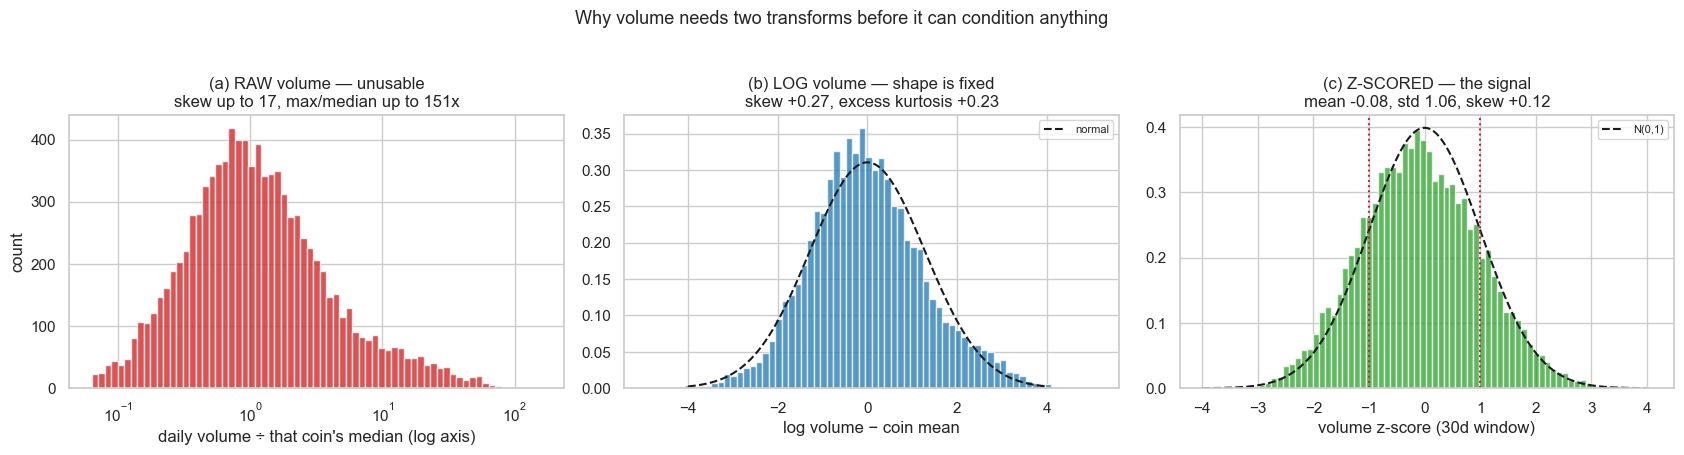

fraction of coin-days with z > +1: 15.9% | z > +2: 2.8% | z < -1: 19.9%
=> the z-score is close to N(0,1) but with a mild right tail: volume SPIKES up, it does not
   spike down. That asymmetry is why the high-z bucket is the interesting one.


In [35]:
# --- Volume distributions: raw, logged, and z-scored --------------------------
dvol_d  = hvol.resample('1D').sum()                     # daily volume, liquid 9
lvol_d  = np.log(dvol_d.replace(0, np.nan))
VZ_WIN  = 30
vz      = ((lvol_d - lvol_d.rolling(VZ_WIN).mean()) / lvol_d.rolling(VZ_WIN).std()).shift(1)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))

# (a) raw volume, each coin scaled by its own median so they are comparable at all
rawn = train_only(dvol_d).div(train_only(dvol_d).median())
ax[0].hist(rawn.stack().dropna(), bins=np.logspace(-1.2, 2.2, 70), color='tab:red', alpha=.8)
ax[0].set_xscale('log'); ax[0].set_xlabel('daily volume ÷ that coin\'s median (log axis)')
ax[0].set_ylabel('count')
ax[0].set_title(f'(a) RAW volume — unusable\nskew up to {train_only(dvol_d).skew().max():.0f}, '
                f'max/median up to {(train_only(dvol_d).max()/train_only(dvol_d).median()).max():.0f}x')

# (b) log volume, per-coin demeaned so the 9 coins overlay on one scale
lc = train_only(lvol_d) - train_only(lvol_d).mean()
xs = np.linspace(-4, 4, 200)
ax[1].hist(lc.stack().dropna(), bins=70, density=True, color='tab:blue', alpha=.75)
ax[1].plot(xs, stats.norm.pdf(xs, 0, lc.stack().std()), 'k--', lw=1.5, label='normal')
ax[1].set_xlabel('log volume − coin mean'); ax[1].legend(fontsize=8)
ax[1].set_title(f'(b) LOG volume — shape is fixed\nskew {lc.stack().skew():+.2f}, '
                f'excess kurtosis {lc.stack().kurtosis():+.2f}')

# (c) the z-score actually used as the signal
zs = train_only(vz).stack().dropna()
ax[2].hist(zs, bins=70, density=True, color='tab:green', alpha=.75)
ax[2].plot(xs, stats.norm.pdf(xs, 0, 1), 'k--', lw=1.5, label='N(0,1)')
ax[2].axvline(1, color='crimson', ls=':', lw=1.4); ax[2].axvline(-1, color='crimson', ls=':', lw=1.4)
ax[2].set_xlabel(f'volume z-score ({VZ_WIN}d window)'); ax[2].legend(fontsize=8)
ax[2].set_title(f'(c) Z-SCORED — the signal\nmean {zs.mean():+.2f}, std {zs.std():.2f}, '
                f'skew {zs.skew():+.2f}')
fig.suptitle('Why volume needs two transforms before it can condition anything', y=1.03, fontsize=13)
fig.tight_layout(); plt.show()
print(f'fraction of coin-days with z > +1: {(zs > 1).mean():.1%} | z > +2: {(zs > 2).mean():.1%} '
      f'| z < -1: {(zs < -1).mean():.1%}')
print('=> the z-score is close to N(0,1) but with a mild right tail: volume SPIKES up, it does not')
print('   spike down. That asymmetry is why the high-z bucket is the interesting one.')


mean log-volume gap (busy half − quiet half) = +0.364  => the 12:00–24:00 half trades about 1.44x the 00:00–12:00 half
gap is positive in 78% of days -- a stable structural feature, not noise


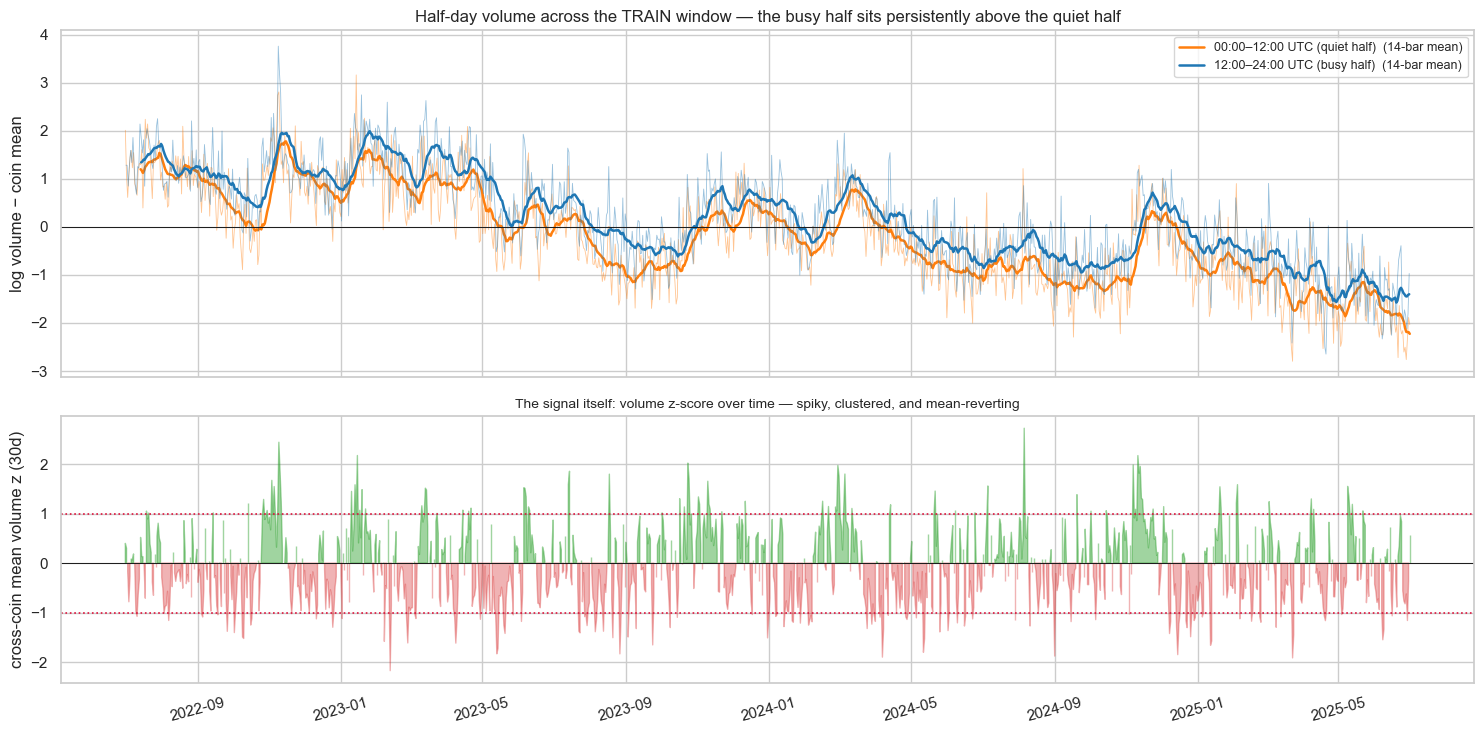


autocorrelation of the cross-coin mean volume z: lag1 0.54, lag5 0.14, lag20 0.04
=> volume activity CLUSTERS: a high-volume day is followed by more high-volume days.


In [36]:
# --- Half-day volume over the TRAIN window ------------------------------------
hv12 = hvol.resample('12h').sum()
lv12 = np.log(hv12.replace(0, np.nan))
lv12 = train_only(lv12)
half  = lv12.index.hour                                  # 0 => 00:00-12:00 UTC, 12 => 12:00-24:00

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7.5), sharex=True,
                               gridspec_kw={'height_ratios': [1.3, 1]})

# per-coin demeaned so all 9 sit on one axis; plot the cross-coin mean for each half-day
cent = lv12 - lv12.mean()
for hh, col, lbl in [(0, 'tab:orange', '00:00–12:00 UTC (quiet half)'),
                     (12, 'tab:blue',  '12:00–24:00 UTC (busy half)')]:
    s = cent[half == hh].mean(axis=1)
    ax1.plot(s.index, s, lw=.6, alpha=.45, color=col)
    ax1.plot(s.index, s.rolling(14).mean(), lw=1.8, color=col, label=f'{lbl}  (14-bar mean)')
ax1.axhline(0, color='k', lw=.7)
ax1.set_ylabel('log volume − coin mean'); ax1.legend(fontsize=9, loc='upper right')
ax1.set_title('Half-day volume across the TRAIN window — the busy half sits persistently above the quiet half')

gap = cent[half == 12].mean(axis=1).reindex(cent[half == 0].mean(axis=1).index, method='nearest') \
      - cent[half == 0].mean(axis=1)
print(f'mean log-volume gap (busy half − quiet half) = {gap.mean():+.3f}  '
      f'=> the 12:00–24:00 half trades about {np.exp(gap.mean()):.2f}x the 00:00–12:00 half')
print(f'gap is positive in {(gap > 0).mean():.0%} of days -- a stable structural feature, not noise')

# rolling z of daily volume underneath, to show what the SIGNAL looks like over time
zc = train_only(vz).mean(axis=1)
ax2.fill_between(zc.index, zc, 0, where=(zc >= 0), color='tab:green', alpha=.45)
ax2.fill_between(zc.index, zc, 0, where=(zc < 0),  color='tab:red',   alpha=.35)
ax2.axhline(0, color='k', lw=.7)
ax2.axhline(1, color='crimson', ls=':', lw=1.2); ax2.axhline(-1, color='crimson', ls=':', lw=1.2)
ax2.set_ylabel(f'cross-coin mean volume z ({VZ_WIN}d)')
ax2.set_title('The signal itself: volume z-score over time — spiky, clustered, and mean-reverting', fontsize=10)
ax2.tick_params(axis='x', labelrotation=15)
fig.tight_layout(); plt.show()
print(f'\nautocorrelation of the cross-coin mean volume z: '
      f'lag1 {zc.autocorr(1):.2f}, lag5 {zc.autocorr(5):.2f}, lag20 {zc.autocorr(20):.2f}')
print('=> volume activity CLUSTERS: a high-volume day is followed by more high-volume days.')


=== the ladder, easiest target to hardest ===
  1. next-day LOG VOLUME       ~ z               beta    +0.260 | t naive  +7.63 | t CLUSTERED  +7.70
  2. next-day |RETURN| (bps)   ~ z               beta   +36.950 | t naive +13.01 | t CLUSTERED  +5.84
  3. next-day SIGNED ret (bps) ~ z               beta   +15.406 | t naive  +3.95 | t CLUSTERED  +1.72
  3b. same, MARKET REMOVED     ~ z               beta    +0.307 | t naive  +0.13 | t CLUSTERED  +0.15
  => the apparent directional result in (3) is entirely the market. Once the common move
     is stripped out it is exactly zero. Volume forecasts RISK, not RETURN.



,n,mean_abs_ret_bps,mean_signed_ret_bps,pct_up
bucket,,,,
z < -1,1960,248.4000,-15.8000,48.6000
-1 to -0.5,1548,250.9000,0.9000,50.0000
-0.5 to 0.5,3470,267.7000,6.0000,49.1000
0.5 to 1,1329,296.1000,18.5000,52.4000
1 to 2,1294,338.0000,21.0000,51.8000
z > 2,272,465.7000,64.9000,54.0000


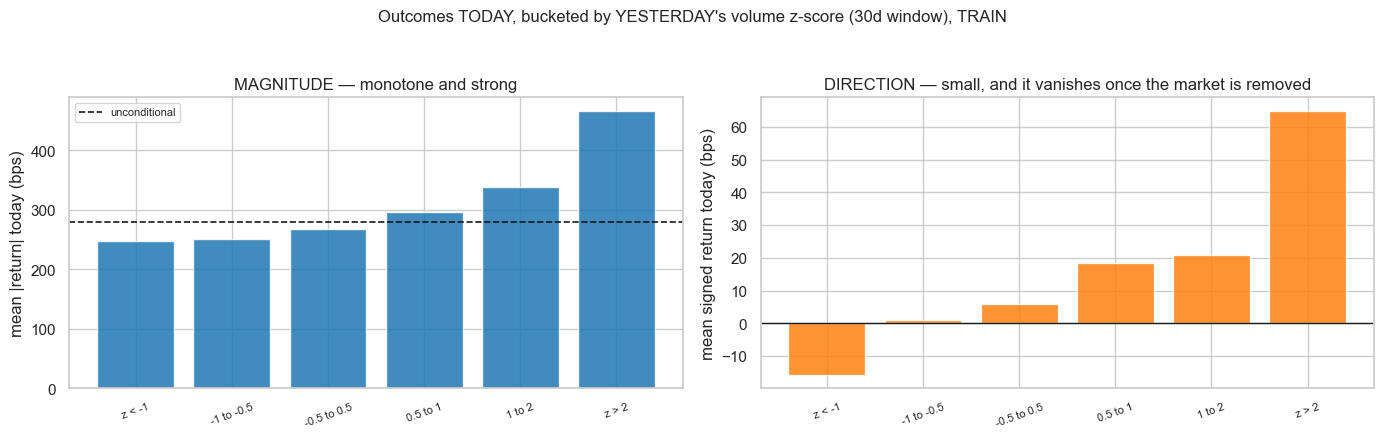

after z > +1: mean |return| 360 bps (+29% vs unconditional 280)
after z < -1: mean |return| 248 bps (-11%)



--- sensitivity to the z-score window x ---


,|ret| beta_bps,|ret| t_clustered,volume t_clustered
10,27.7900,4.7000,5.6000
20,33.9800,5.5300,6.7800
30,36.9500,5.8400,7.7000
60,43.4400,6.6500,11.6800
120,47.0700,7.7200,15.9400


=> the effect strengthens with a longer baseline window and is not knife-edge in x.

WHAT THIS IS GOOD FOR: volume z is a RISK forecaster, not a return forecaster. It cannot
tell the XS momentum book which coins to hold, but it can tell it HOW BIG to be -- scale
gross exposure down when z is high. That pairs with the volatility findings in the EDA
(vol is ~0.69 correlated across coins with an ~18-day half-life, i.e. forecastable).


In [37]:
# --- Test C: what does a high volume z-score actually predict? ----------------
_R = np.log(XS_PX).diff()

def zpanel(y, z):
    d = pd.concat([train_only(y).stack().rename('y'),
                   train_only(z).stack().rename('z')], axis=1).dropna()
    d['date'] = d.index.get_level_values(0)
    return d

def ztest(y, z, lbl):
    d = zpanel(y, z)
    f  = sm.OLS(d.y, sm.add_constant(d.z)).fit()
    fc = sm.OLS(d.y, sm.add_constant(d.z)).fit(cov_type='cluster', cov_kwds={'groups': d.date})
    print(f'  {lbl:46s} beta {f.params["z"]:+9.3f} | t naive {f.tvalues["z"]:+6.2f} '
          f'| t CLUSTERED {fc.tvalues["z"]:+6.2f}')

print('=== the ladder, easiest target to hardest ===')
ztest(lvol_d,        vz, '1. next-day LOG VOLUME       ~ z')
ztest(_R.abs() * 1e4, vz, '2. next-day |RETURN| (bps)   ~ z')
ztest(_R * 1e4,       vz, '3. next-day SIGNED ret (bps) ~ z')
_Rx = _R.sub(_R.mean(axis=1), axis=0)          # strip the common market move
ztest(_Rx * 1e4,      vz, '3b. same, MARKET REMOVED     ~ z')
print('  => the apparent directional result in (3) is entirely the market. Once the common move')
print('     is stripped out it is exactly zero. Volume forecasts RISK, not RETURN.\n')

# --- the bucket table: the picture behind those regressions ---
d = pd.concat([train_only(vz).stack().rename('z'),
               train_only(_R.abs()).stack().rename('absret'),
               train_only(_R).stack().rename('ret')], axis=1).dropna()
d['bucket'] = pd.cut(d.z, [-np.inf, -1, -.5, .5, 1, 2, np.inf],
                     labels=['z < -1', '-1 to -0.5', '-0.5 to 0.5', '0.5 to 1', '1 to 2', 'z > 2'])
tab = d.groupby('bucket', observed=True).agg(
    n=('z', 'size'),
    mean_abs_ret_bps=('absret', lambda s: s.mean() * 1e4),
    mean_signed_ret_bps=('ret', lambda s: s.mean() * 1e4),
    pct_up=('ret', lambda s: (s > 0).mean() * 100))
display(tab.round(1))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].bar(range(len(tab)), tab.mean_abs_ret_bps, color='tab:blue', alpha=.85)
ax[0].axhline(d.absret.mean() * 1e4, color='k', ls='--', lw=1.2, label='unconditional')
ax[0].set_xticks(range(len(tab))); ax[0].set_xticklabels(tab.index, rotation=20, fontsize=8)
ax[0].set_ylabel('mean |return| today (bps)'); ax[0].legend(fontsize=8)
ax[0].set_title('MAGNITUDE — monotone and strong')
ax[1].bar(range(len(tab)), tab.mean_signed_ret_bps, color='tab:orange', alpha=.85)
ax[1].axhline(0, color='k', lw=1)
ax[1].set_xticks(range(len(tab))); ax[1].set_xticklabels(tab.index, rotation=20, fontsize=8)
ax[1].set_ylabel('mean signed return today (bps)')
ax[1].set_title('DIRECTION — small, and it vanishes once the market is removed')
fig.suptitle(f'Outcomes TODAY, bucketed by YESTERDAY\'s volume z-score ({VZ_WIN}d window), TRAIN',
             y=1.04, fontsize=12)
fig.tight_layout(); plt.show()

hi, lo = d[d.z > 1], d[d.z < -1]
print(f'after z > +1: mean |return| {hi.absret.mean()*1e4:.0f} bps '
      f'({hi.absret.mean()/d.absret.mean()-1:+.0%} vs unconditional {d.absret.mean()*1e4:.0f})')
print(f'after z < -1: mean |return| {lo.absret.mean()*1e4:.0f} bps '
      f'({lo.absret.mean()/d.absret.mean()-1:+.0%})')

# --- how does the window x change things? ---
win = {}
for x in [10, 20, 30, 60, 120]:
    zx = ((lvol_d - lvol_d.rolling(x).mean()) / lvol_d.rolling(x).std()).shift(1)
    dd = zpanel(_R.abs() * 1e4, zx)
    fc = sm.OLS(dd.y, sm.add_constant(dd.z)).fit(cov_type='cluster', cov_kwds={'groups': dd.date})
    ddv = zpanel(lvol_d, zx)
    fv = sm.OLS(ddv.y, sm.add_constant(ddv.z)).fit(cov_type='cluster', cov_kwds={'groups': ddv.date})
    win[x] = {'|ret| beta_bps': fc.params['z'], '|ret| t_clustered': fc.tvalues['z'],
              'volume t_clustered': fv.tvalues['z']}
print('\n--- sensitivity to the z-score window x ---')
display(pd.DataFrame(win).T.round(2))
print('=> the effect strengthens with a longer baseline window and is not knife-edge in x.')
print()
print('WHAT THIS IS GOOD FOR: volume z is a RISK forecaster, not a return forecaster. It cannot')
print('tell the XS momentum book which coins to hold, but it can tell it HOW BIG to be -- scale')
print('gross exposure down when z is high. That pairs with the volatility findings in the EDA')
print('(vol is ~0.69 correlated across coins with an ~18-day half-life, i.e. forecastable).')
